# Project 3 - Simulation of phase separation in a binary mixture

## Task 1

>**Task 1.1**

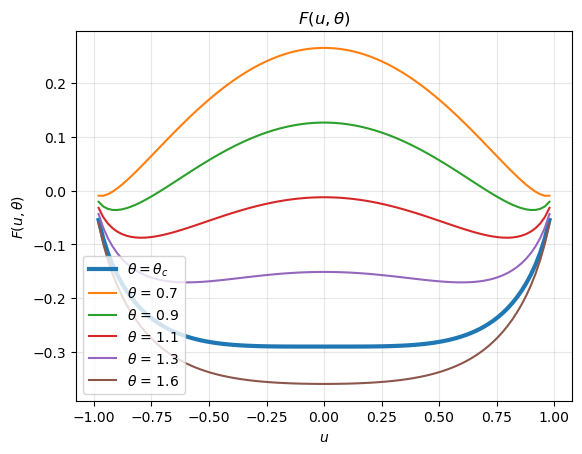

In [1]:
import numpy as np
import matplotlib.pyplot as plt

theta_c   = 1.5                                 # Critical temperature
theta_arr = np.array([0.7, 0.9, 1.1, 1.3, 1.6]) # Different values for temperature
u         = np.linspace(-1,1, 100)[1:-1]        # Slicing to avoid using -1 and 1

def F(u, theta):
    '''
    Plots the energy density, F(u), for different values of theta.

    Parameters:
    ----------- 
        u (ndarray)   : 1D array of the concentration of mass.
        theta (float) : The temperature.

    Returns:
    ----------- 
        F (ndarray) : 1D array of the energy density.
    '''
    F = (theta_c / 2) * (1-u**2) + (theta/2) * ( (1-u) * np.log((1-u)/2) + (1+u) * np.log((1+u)/2) )
    return F

plt.plot(u,F(u, theta_c), label = f'$\\theta = \\theta_c$', linewidth=3)
for theta in theta_arr:
    plt.plot(u,F(u, theta), label = f'$\\theta$ = {theta}')

plt.legend(loc= 'lower left')
plt.xlabel('$u$')
plt.ylabel('$F(u, \\theta )$')
plt.title('$F(u, \\theta)$')
plt.grid(alpha = 0.3)
plt.show()

We observe that as the temperature $\theta$ decreases, the peak of the Helmholtz free energy is much sharper, and the potential difference between the local extrema in $u = 0$ and the minima in $u \in \{-1,1\}$ is greater at lower temperatures. We also see that the peak disappears almost completely for temperatures $\theta >\theta_c$, which theoretically marks the lowest temperature at which phase separation can occur. At $\theta < \theta_c$, the peak separates the different phases, tending to different potential wells. 

>**Task 1.2**

From the Cahn-Hilliard equation, given by

\begin{align}
    \partial_tu  -  \nabla \cdot\left(M\nabla\left(f(u)-\kappa\nabla^2u \right)\right) = 0,
\end{align}

where $u = u(\vec{x}, t) \ \vert \ \vec{x} = (x,y)$, we will observe step by step what happens under the transformation $u \rightarrow-u$.

By the linearity of the derivative, we have that

\begin{align}
    \partial_tu &\rightarrow \partial_t(-u) = -\partial_tu \\
    \nabla^2u &\rightarrow \nabla^2(-u) = -\nabla^2u,\\
\end{align}

and since $f$ is an anti-symmetric function, we have that

\begin{align}
    f(u) &\rightarrow f(-u) = -f(u)\\
    \implies  M\nabla\left(f(u)-\kappa\nabla^2u \right) &\rightarrow M\nabla\left(f(-u)+\kappa\nabla^2u \right) = -M\nabla\left(f(u)-\kappa\nabla^2u \right) \\
    \implies \nabla \cdot\left(M\nabla\left(f(u)-\kappa\nabla^2u \right)\right) &\rightarrow -\nabla \cdot\left(M\nabla\left(f(u)-\kappa\nabla^2u \right)\right).
\end{align}

Hence, we have that the equation as a whole transforms into,

\begin{align}
    &\partial_tu  -  \nabla \cdot\left(M\nabla\left(f(u)-\kappa\nabla^2u \right)\right) = 0 \\ \rightarrow& -\partial_tu  +  \nabla \cdot\left(M\nabla\left(f(u)-\kappa\nabla^2u \right)\right) = 0\\
    &\partial_tu  -  \nabla \cdot\left(M\nabla\left(f(u)-\kappa\nabla^2u \right)\right) = 0
\end{align}

Thus, $-u$ also solves the Cahn-Hilliard equation and is invariant under transformation.

q.e.d.

>**Task 1.3**

Taking the Cahn-Hilliard equation as stated above, multiplying by 1, and integrating over $\Omega = [0,L_x) \times[0,L_y)$, we get,

\begin{equation}
    \int_{\Omega}\partial_tu \ d\vec{x}  - \int_{\Omega} \nabla \cdot\left(M\nabla\left(f(u)-\kappa\nabla^2u \right)\right) \ d\vec{x} = 0.
\end{equation}

The first integral has an integration domain independent of the partial derivative operator inside the integral, and therefore we can move the derivative operator outside and make it a total derivative,

\begin{equation}
    \int_{\Omega}\partial_tu \ d\vec{x} = \frac{d}{dt}\int_{\Omega}u \ d\vec{x}.
\end{equation}

Continuing, we want to use the divergence theorem, which is generally stated as

\begin{equation}   
\int_{\Omega} \nabla \cdot \mathbf{F} \, dV = \oint_{\partial \Omega}\hat{n}\cdot \mathbf{F}  \ dS, 
\end{equation}

with $\hat{n}$ being the outward-pointing unit normal to the boundary $ \partial \Omega $, and $dS$ representing the surface element of the boundary. 
In our case, we can define

\begin{equation}
    F(x,y) = M\nabla\left(f(u)-\kappa\nabla^2u \right)
\end{equation}

and by the periodicity of our domain, we have that $F(0,y) = F(L_x, y)$ and $F(x,0) = F(x, L_y)$. 
Taking a look at the boundary and its direction, plotted here,

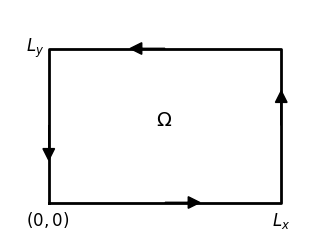

we clearly see that the integral over the left and right boundary segments will cancel out, and likewise with the top and bottom of the boundary. Thus

\begin{equation}   
\oint_{\partial \Omega}\hat{n}\cdot \mathbf{F}  \ dS = 0
\end{equation}

and we are left with

\begin{equation}
    \frac{d}{dt}\int_{\Omega}u \ d\vec{x} = 0.
\end{equation}

The system is therefore mass-conservative, since we showed that the boundary integral, which could be considered the mass-flux through our domain is, in total, zero.

q.e.d.

## Task 2

By Fourier-transformation of the biharmonic equation with a linear term we get

\begin{align}
    \Delta^2u +  cu& = f \\
    \mathcal{F}[\Delta^2 u +cu] &= \hat{f} \\
    \mathcal{F}[\Delta^2u] +c\hat{u} &= \hat{f} \\
    (i\tilde{k})^4\hat{u}+c\hat{u} &= \hat{f}\\
    (\lvert\tilde{k}\rvert^4+c)\hat{u} &= \hat{f}.
\end{align}

So, our operator transforms as $\{\Delta^2 + c\}\rightarrow\{\lvert\tilde{k}\rvert^4+c\}$ under the Fourier transform, which will be implemented in the code under.

In [2]:
from scipy.fft import fft2, ifft2, fftfreq

def biharmonic_solver(X, Y, F, c, mean=0.0):
    """
    Solve the biharmonic equation in 2D using the spectral method.

    Parameters:
    ----------- 
        X (ndarray)   : 2D array of x-coordinates.
        Y (ndarray)   : 2D array of y-coordinates.
        F (ndarray)   : 2D array representing the right-hand side of the biharmonic equation.
        c (float)     : Constant coefficient in the biharmonic equation.
        mean (float)  : Desired mean value of the solution in case c = 0. Default is 0.0.

    Returns:
    ----------- 
        U (ndarray)   : 2D array representing the solution to the biharmonic equation.
    """

    F_hat = fft2(F) # Compute the FFT of the right-hand side using the 2D FFT

    # Prepare relevant data for Fourier transform
    x, y   = X[:, 0], Y[0, :]
    Nx, Ny = X.shape
    dx, dy = (x[1]- x[0]), (y[1] - y[0])

    # Transforms the 2D space to a Fourier frequency space
    kx, ky = fftfreq(Nx, d=dx) * 2j * np.pi, fftfreq(Ny, d=dy) * 2j * np.pi
    KX, KY = np.meshgrid(kx, ky, indexing='ij', sparse=True)

    # Computing the biharmoic operator in Fourier space
    K_op = (KX**2 + KY**2)**2 + c
    if c == 0: K_op[0, 0] = 1  # Avoid division by zero

    # Solve the biharmonic equation in Fourier space
    U_hat = F_hat / K_op
    if c == 0: U_hat[0, 0] = mean * Nx * Ny # Corrects the K_op = 0 scenario by setting it as a mean value

    U = ifft2(U_hat).real # Compute the inverse FFT to obtain the final solution in spatial domain

    return U

In [3]:
import sympy as sy
from sympy import sin, cos, exp

def biharmonic_solver_sym(u_str, c):
    """
    Uses SymPy to solve the biharmonic equation (f(x, y) = Δ²u + c * u) for a given string of the function u(x, y).
    Returns the function u(x, y) and f(x, y) as NumPy functions. Also prints them out to check for correct input and output.

    Parameters:
    ----------- 
        u_str (str) : String representation of the function u(x, y).
        c (float)   : Constant coefficient in the biharmonic equation.

    Returns:
    ----------- 
        u (callable) : NumPy-compatible function representing u(x, y).
        f (callable) : NumPy-compatible function representing f(x, y).
    """

    x, y = sy.symbols('x y') # Define symbolic variables x and y
    u_sy = eval(u_str)       # Convert the input string representation of u into a SymPy expression

    # Solves the equation with SymPy functions
    biharmonic_op = lambda u: sy.diff(u, x, 4) + sy.diff(u, y, 4) + 2 * sy.diff(sy.diff(u, x, 2), y, 2)
    f_sy = sy.simplify(biharmonic_op(u_sy) + (c * u_sy))

    # Print out the symbolic expressions for verification
    print(f'u = {u_sy}')
    print(f'f = {f_sy}')

    # Convert symbolic expressions into NumPy-compatible functions
    u = sy.lambdify((x, y), u_sy, modules='numpy')
    f = sy.lambdify((x, y), f_sy, modules='numpy')

    return u, f

u_ex_str2_1 = "sin(8*(x - 1)) * cos(4*y)"
u_ex_str2_2 = "exp((sin(x))**2 + cos(2*y))"
u_ex2_1, f2_1 = biharmonic_solver_sym(u_ex_str2_1, 1)
u_ex2_2, f2_2 = biharmonic_solver_sym(u_ex_str2_2, 0)

u = sin(8*x - 8)*cos(4*y)
f = 6401*sin(8*x - 8)*cos(4*y)
u = exp(sin(x)**2 + cos(2*y))
f = (16*sin(x)**8 + 64*sin(x)**6 + 128*sin(x)**4*sin(y)**4 - 192*sin(x)**4*sin(y)**2 + 16*sin(x)**4 - 48*sin(x)**2 + 256*sin(y)**8 - 1280*sin(y)**6 + 1792*sin(y)**4 - 768*sin(y)**2 + 52)*exp(sin(x)**2 + cos(2*y))


To analyze our solvers credibility, we want to compute the Experimental Order of Convergence (EOC), defined as

\begin{equation}
    \text{EOC}(i) = \frac{\log(e(\tau_i)) - \log(e(\tau_{i-1}))}{\log(\tau_i) - \log(\tau_{i-1})} = \frac{\log\left(\frac{e(\tau_i)}{e(\tau_{i-1})}\right)}{\log\left(\frac{\tau_i}{\tau_{i-1}}\right)}
\end{equation}

with $e(\tau_i)$ being the maximum error at the step size $\tau_i$. This is used to estimate the order of convergence for our methods, and also later, verify that our implemented methods corresponds to the correct theoretical methods.
For this task, the step size $\tau_i$ refers to the distances $dx$ and $dy$, but for later tasks it refers to the time steps $dt$.

In [4]:
# Define the domain
Lx0, Ly0 = 2*np.pi, 4*np.pi

# Define 1d step numbers for x and y directions
Nx1 = np.array([4, 8, 15, 16, 20, 32])
Ny1 = 2* Nx1
Nx2 = np.arange(4, 40+1, 4)
Ny2 = 2* Nx2

def compute_EOC_NxNy(Nx_arr, Ny_arr, Lx, Ly, u_ex, f, c):
    """
    Perform convergence study for given grid sizes, calculating errors and experimental order of convergence.

    Parameters:
    ----------- 
        Nx_arr (ndarray) : 1D array of Nx grid sizes to test.
        Ny_arr (ndarray) : 1D array of Ny grid sizes corresponding to Nx.
        Lx (float)       : Length of the domain in the x-direction.
        Ly (float)       : Length of the domain in the y-direction.
        u_ex (callable)  : Exact solution function, u(X, Y).
        f (callable)     : Right-hand side function, f(X, Y).
        c (float)        : Constant in the biharmonic equation.

    Returns:
    ----------- 
        errors (ndarray) : 1D array of errors for each grid size relating to Nx/Nt
        EOCs (ndarray)   : 1D array of experimental order of convergence as a relation from previous grid size.
    """
    errors_list = []
    d_list = []

    # Loop over grid sizes
    for i in range(len(Nx_arr)):
        Nx, Ny = Nx_arr[i], Ny_arr[i]
        x = np.linspace(0, Lx, Nx, endpoint=False)
        y = np.linspace(0, Ly, Ny, endpoint=False)
        X, Y = np.meshgrid(x, y, indexing='ij')

        # Evaluate exact solution and right-hand side
        U_exact = u_ex(X, Y)
        F = f(X, Y)
        
        # Calculation of exact mean (used when c = 0)
        mean_ex = np.mean(U_exact)

        # Solve numerical solution
        U_num = biharmonic_solver(X, Y, F, c, mean=mean_ex)

        # Compute max-norm error and step size
        errors_list.append(np.max(np.abs(U_num - U_exact)))
        d_list.append(x[1]- x[0])
    
    # Make lists to arrays for further calcualtions
    errors = np.array(errors_list)
    d      = np.array(d_list)

    # Compute EOC values
    EOCs = np.log(errors[1:]/errors[:-1])/np.log(d[1:]/d[:-1])

    return errors, EOCs

def plot_convergence(Ni_arr, Ni_name, errors, EOCs):
    """
    Plot the errors and EOCs in a table format for any given Ni (Nx/Ny/Nt).

    Parameters:
    ----------- 
        Ni_arr (ndarray) : 1D array of Ni step sizes.
        Ni_name (string) : Name of the step dimension plotted against.
        errors (ndarray) : 1D array of errors.
        EOCs (ndarray)   : 1D array of EOC values.
    """
    print(f"\n{Ni_name:<15}{'Error':<25}{'EOC':<15}")
    print("-" * 50)
    for i in range(len(Ni_arr)):
        EOC = EOCs[i-1] if i > 0 else None
        if EOC is None:
            print(f"{Ni_arr[i]:<15}{errors[i]:<25.6e}{'--':<15}")
        else:
            print(f"{Ni_arr[i]:<15}{errors[i]:<25.6e}{EOC:<15.4f}")

# Run convergence studies
errors2_1, EOCs2_1 = compute_EOC_NxNy(Nx1, Ny1, Lx0, Ly0, u_ex2_1, f2_1, c=1)
errors2_2, EOCs2_2 = compute_EOC_NxNy(Nx2, Ny2, Lx0, Ly0, u_ex2_2, f2_2, c=0)

# Plot the results
print(f"\nConvergence studies for u(x, y) = {u_ex_str2_1}:")
plot_convergence(Nx1, "Nx", errors2_1, EOCs2_1)
print(f"\n\nConvergence studies for u(x, y) = {u_ex_str2_2}:")
plot_convergence(Nx2, "Nx", errors2_2, EOCs2_2)


Convergence studies for u(x, y) = sin(8*(x - 1)) * cos(4*y):

Nx             Error                    EOC            
--------------------------------------------------
4              6.331893e+03             --             
8              2.365221e+01             8.0645         
15             5.136364e-01             6.0923         
16             5.884182e-15             497.3815       
20             3.261280e-14             -7.6742        
32             4.873879e-14             -0.8548        


Convergence studies for u(x, y) = exp((sin(x))**2 + cos(2*y)):

Nx             Error                    EOC            
--------------------------------------------------
4              2.024104e+01             --             
8              1.062305e+01             0.9301         
12             9.844063e-01             5.8667         
16             3.462556e-02             11.6359        
20             9.929320e-04             15.9166        
24             3.601909e-05             1

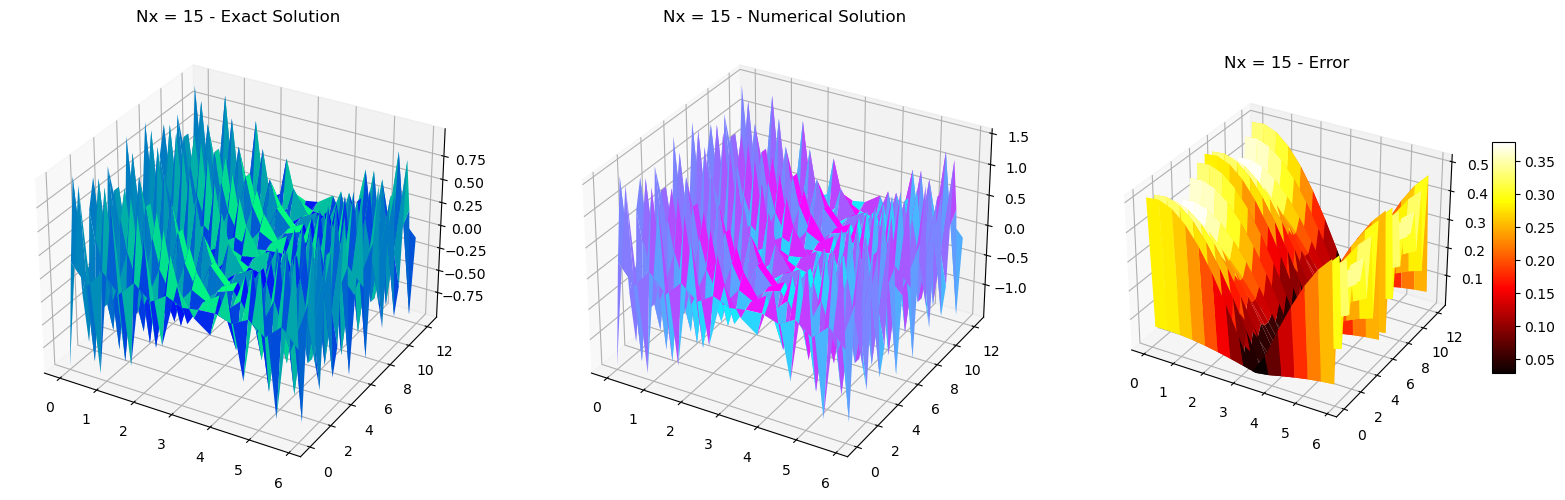

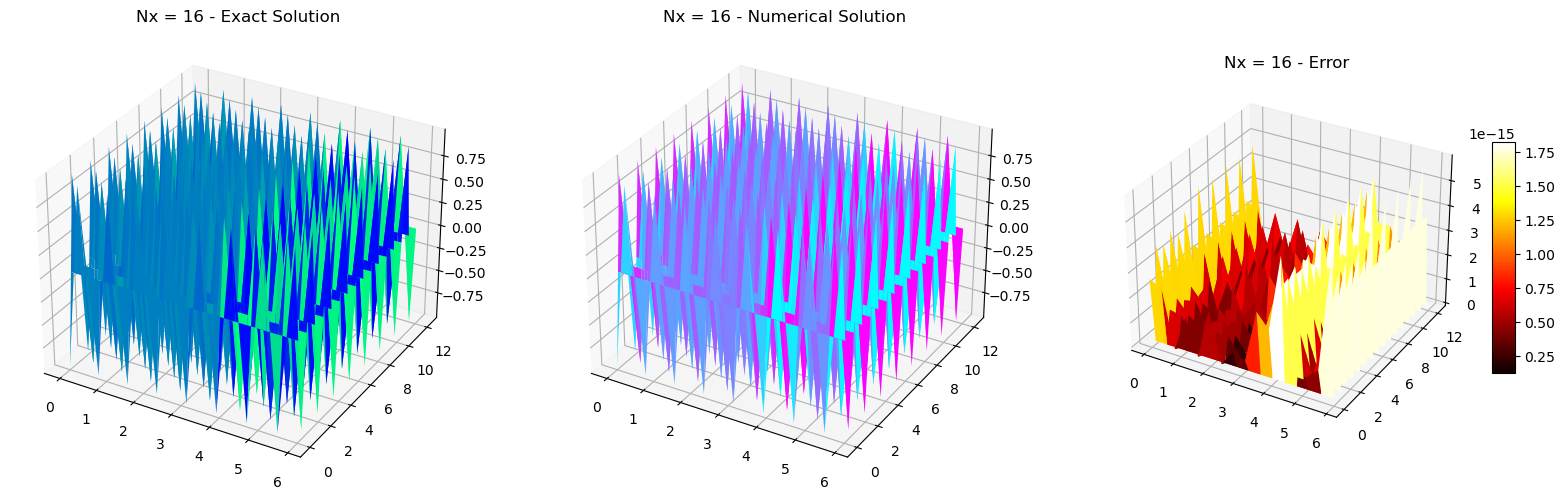

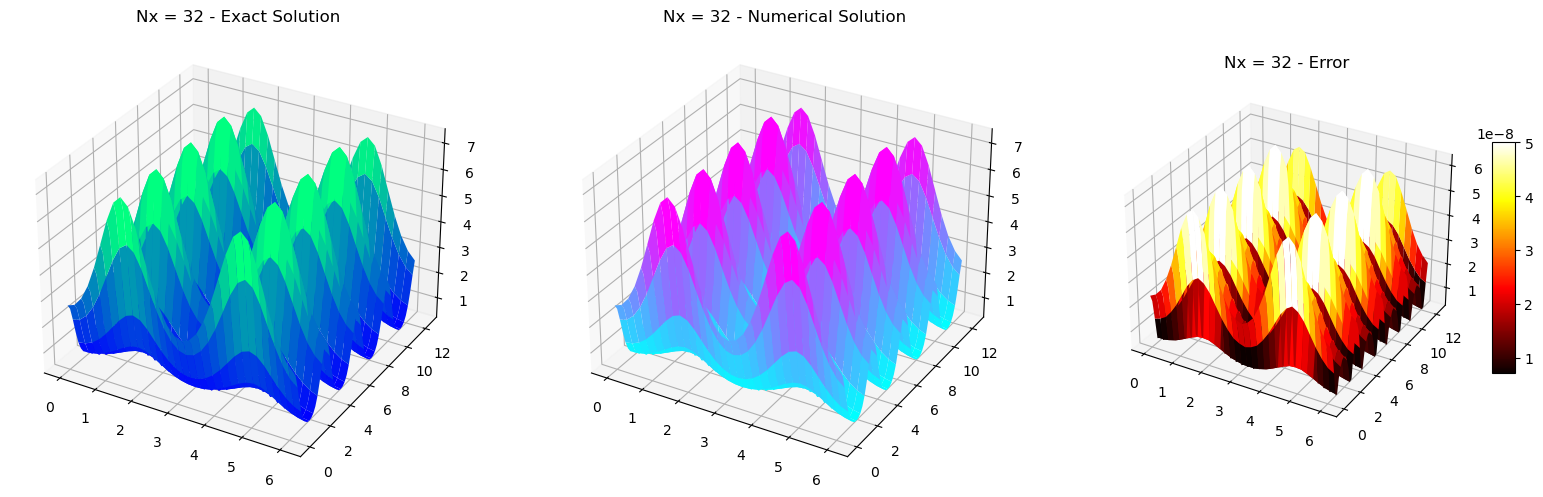

In [5]:
def plot_surface(X, Y, U_exact, U_num, error, title):
    """
    Plots 3D surface graphs for the exact solution, numerical solution, and error of a function
    on a given grid.

    Parameters:
    ----------- 
        X (ndarray)       : 2D array of x-coordinates for the grid.
        Y (ndarray)       : 2D array of y-coordinates for the grid.
        U_exact (ndarray) : 2D array representing the exact solution values of u(X, Y).
        U_num (ndarray)   : 2D array representing the numerical (computed) solution values of u(X, Y).
        error (ndarray)   : 2D array representing the difference between U_exact and U_num.
        title (str)       : Title for the plots.
    """

    fig = plt.figure(figsize=(20, 6))

    # Plot exact solution
    ax1   = fig.add_subplot(131, projection='3d')
    surf1 = ax1.plot_surface(X, Y, U_exact, cmap='winter')
    ax1.set_title(f'{title} - Exact Solution')

    # Plot numerical solution
    ax2   = fig.add_subplot(132, projection='3d')
    surf2 = ax2.plot_surface(X, Y, U_num, cmap='cool')
    ax2.set_title(f'{title} - Numerical Solution')

    # Plot error
    ax3   = fig.add_subplot(133, projection='3d')
    surf3 = ax3.plot_surface(X, Y, error, cmap='hot')
    ax3.set_title(f'{title} - Error')
    fig.colorbar(surf3, ax=ax3, shrink=0.5, aspect=10)

    plt.show()

# Nx and Ny values to be plotted
Nx_values = np.array([15, 16, 32])
Ny_values = 2 * Nx_values

# Loops all the plotting og the grid sizes and functions wich
for i, Nx in enumerate(Nx_values):
    Ny   = Ny_values[i]
    x    = np.linspace(0, Lx0, Nx, endpoint=False)
    y    = np.linspace(0, Ly0, Ny, endpoint=False)
    X, Y = np.meshgrid(x, y, indexing='ij')

    # Evaluate exact solution and right-hand side
    U_exact = u_ex2_1(X, Y) if i < 2 else u_ex2_2(X, Y)
    F       = f2_1(X, Y) if i < 2 else f2_2(X, Y)
    mean    = np.mean(U_exact)

    # Solve numerical solution
    U_num = biharmonic_solver(X, Y, F, 1, mean=mean) if i < 2 else biharmonic_solver(X, Y, F, 0, mean=mean)

    # Compute error
    error = np.abs(U_num - U_exact)

    # Plot the surfaces for each case
    plot_surface(X, Y, U_exact, U_num, error, f"Nx = {Nx}")

In our EOC analysis we can make som key observations straight away.
For the first manufactured solution, $u(x,y) = \sin(8(x-1))\cos(4y)$, we observe a rather large error for the first couple of $N_x$ values. A sudden change occurs from $N_x = 15$ to $N_x = 16$, with a drastic drop in error, and the EOC for 16 is consequently quite large. For $N_x > 16$ we see some random fluctuations in the error, due to floating point representation errors.

The large error for small $N_x$ is theoretically explained by a phenomenon called aliasing. Aliasing occurs when the sampling of a function is not fine enough to capture the highest frequency fluctuations of the function. When the sampling frequency is too low, the high frequency components will be indistinguishable from lower frequency components, and the coefficients in Fourier space will occur at the same frequency coordinate, and their coefficients will add together, creating data inconsistent with the analytical expression the data was sampled from. By the Nyquist sampling theorem, you avoid aliasing issues by having a sampling rate $N \geq 2p$, where $p$ is the highest frequency present in the analytical expression.

Employing this to $u(x,y) = \sin(8(x-1))\cos(4y)$, we see that the frequencies are 4 in the y-direction and 8 in the x-direction, and the Nyquist sampling rate becomes $N\geq 2\cdot8 = 16$, which is exactly what is observed in our EOC analysis.

Moving to the first two sets of plots, both for the manufactured solution $u(x,y) = \sin(8(x-1))\cos(4y)$, we clearly observe the periodic accumulation of error due to aliasing for $N_x = 15$. This disappears completely in the error plot for $N_x = 16$, as previously discussed. 

Now, considering the second manufactured solution, $u(x,y) = \exp(\sin^2(x) + \cos(2y))$, we calculate the Nyquist sampling rate to be $N \geq 2\cdot 2 = 4$, so all our used values of $N_x$ will avoid aliasing issues. We do however observe a decline in error, and what by first glance seems to be a linear increase in EOC. 
From its definition, a linear increase in the EOC should correspond to an exponential decrease in the error. We have therefore done a simple curve fit to illustrate this.

52.8884636979498 0.2335873309303565


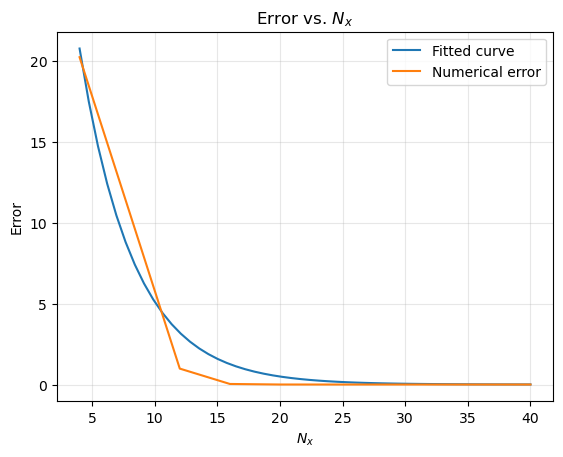

In [6]:
from scipy.optimize import curve_fit

# Further error and EOC analysis for 2nd expression
def exp_decay(x, A, B):
    """
    Function used to fit an exponential decay to the error data.
    
    Parameters:
    -----------
        x (ndarray) : 1D array of x values the function is valuated over.
        A (float)   : Scalar defining the value at x = 0.
        B (float)   : Scalar defining the slope of the exponential decay.
    
    Returns:
    -----------
        fun (ndarray) : 1D array of the values of the exponential decay for each x value.
    """
    fun = A*np.exp(-B*x)
    return fun


x                  = np.linspace(Nx2[0], Nx2[-1])
params, _          = curve_fit(exp_decay, Nx2, errors2_2, p0=[52,.2])
A_fitted, B_fitted = params

print(A_fitted, B_fitted)

error_fit = exp_decay(x, A_fitted, B_fitted)

plt.plot(x, error_fit, label = 'Fitted curve')
plt.plot(Nx2, errors2_2, label = 'Numerical error')
plt.title(r"Error vs. $N_x$")
plt.xlabel(r"$N_x$")
plt.ylabel(r"Error")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

As we see, the error follows a somewhat exponential decay as $N_x$ increases, which is quite characteristic for spectral and pseudo-spectral methods.

Moving to the surface plots for this manufactured solution, we clearly see that the error follows the same pattern as the function itself, which is because the timestep for steeper changes will not be able to capture the change as well as for the less steep values of the function. 

## Task 3 

>**Theoretical task 3.1**

We are given the equation

\begin{align}
    &U_{n+1} = U_n + \tau \left( \theta F(t_{n+1}, U_{n+1}) + (1 - \theta) F(t_n, U_n) \right), \quad \text{for } n = 0, 1, \dots, N-1 
\end{align}

where

\begin{align}
    &t_{n+1} = t_n+\tau
\end{align}

and have that

\begin{align}
    k_1 &= F(t_n, U_n) \\
    k_2 &= F(t_{n+1}, U_{n+1}).
\end{align}

For $k_2$, we insert the expression for $U_{n+1}$

\begin{align}
    k_2 &= F(t_n+\tau, U_n + \tau(\theta k_2+(1-\theta)k_1))
\end{align}

This gives us a butcher table as follows

\begin{array}{c|cc}
0 & 0 & 0 \\
1 & 1-\theta & \theta \\
\hline
& 1 - \theta & \theta \\
\end{array}




From the butcher table, we can easily check the consistency order of the $\theta$-method.
The $p = 1$ condition, which says

\begin{equation}
    \sum_{i=1}^{2}b_i = (1-\theta) + \theta = 1 \ \forall\ \theta,
\end{equation}

is satisfied. Now taking a look at $p = 2$, which states

\begin{equation}
    \sum_{i=1}^2 b_ic_i = (1-\theta)\cdot0+ \theta\cdot1 = \theta\neq \frac{1}{2} \ \forall \ \theta,
\end{equation}

we see that the condition is not generally satisfied. It does however hold for $\theta = \frac{1}{2}$. So assuming $\theta = \frac{1}{2}$ going forward, we compute the condition for $p = 3$,

\begin{equation}
    \sum_{i=1}^2b_ic_2^2 = \frac{1}{2}\cdot 0^2 + \frac{1}{2}\cdot 1^2 = \frac{1}{2}\neq \frac{1}{3}.
\end{equation}

So the condition for consistency order $p=3$ does not hold.
Therefore, we conclude that $p = 1\ \forall \ \theta \neq \frac{1}{2}$ and $p=2 \ \vert \ \theta = \frac{1}{2}$

For $\theta = \frac{1}{2}$, the method reduces to the Crank-Nicolson method, which is based on the implicit trapezoid rule. 
For $\theta = 0$, we get the explicit Euler method, and for $\theta = 1$ we are left with the implicit Euler method.

>**Theoretical task 3.2**

We use the butcher table for our $\theta$-method, and the ODE, $\partial_tU_n = \lambda U_n = F(t_n,U_n)$, to get,

\begin{align}
    U_{n+1} &= U_n + \tau (\theta\lambda U_{n+1} + (1-\theta)\lambda U_n) \\
    &= (1+\tau(1-\theta)\lambda U_n + \tau\theta\lambda U_{n+1}\\
    (1-\theta z) U_{n+1} &= (1+(1-\theta)z)U_n\\
    U_{n+1} &= \left(\frac{1+(1-\theta)z}{1-\theta z}\right) U_n = \left(\frac{1+(1-\theta)z}{1-\theta z}\right)^n U_0
\end{align}

So our stability function becomes 

\begin{equation}
    r_\theta(z) = \frac{1+(1-\theta)z}{1-\theta z}
\end{equation}

with $z = \tau\lambda.$
Below, we have included some heatmaps of the magnitude of the stability function in the complex plane.

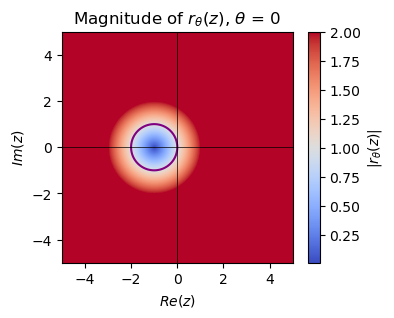

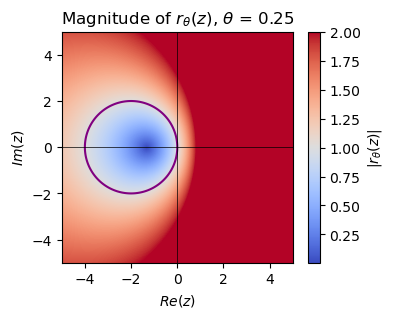

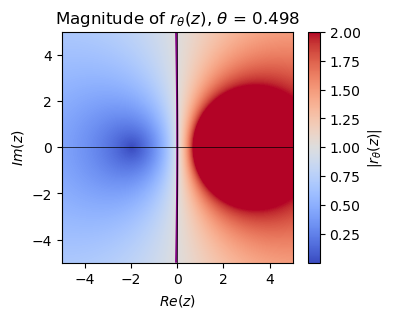

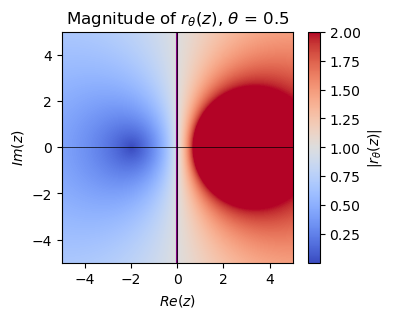

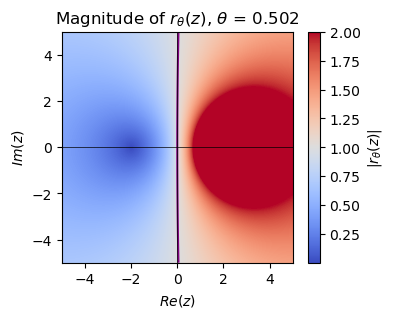

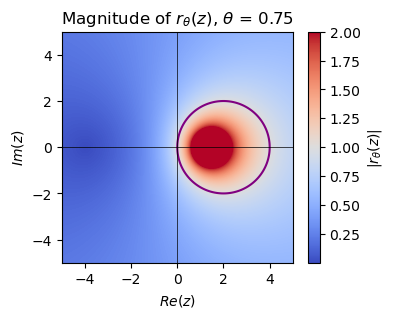

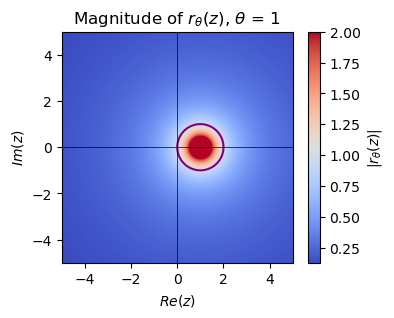

In [7]:
def r_theta(z, theta):
    
    """
    The stability function for the theata method.
    
    Parameters:
    -----------
        z (ndarray)   : 2D array of the complex values the function is to be evaluated over.
        theta (float) : The theta parameter from the theta method.
    
    Returns:
    -----------
        r (ndarray) : 2D array of the values of the stability function for each given z.
    """
    r = (1 + (1-theta)*z) / (1-theta*z)
    return r

# Defines the complex mesh grid
Re   = np.linspace(-5, 5, 500) 
Im   = np.linspace(-5, 5, 500)
X, Y = np.meshgrid(Re, Im)
Z    = X + 1j*Y

theta_arr = [0, .25, .498, .5, .502, .75, 1]

for theta in theta_arr:
    R= r_theta(Z, theta)

    plt.figure(figsize = (4,3))
    plt.contour(X, Y, np.abs(R), levels=[1], colors='purple', linewidths=1.5)
    plt.imshow(np.abs(R), extent=[-5, 5, -5, 5], origin="lower", cmap="coolwarm", vmax = 2)
    plt.colorbar(label= r"|$r_\theta (z)$|")
    plt.axhline(0, color='black', linewidth=.5)  # x-axis
    plt.axvline(0, color='black', linewidth=.5)  # y-axis
    plt.xlabel(r"$Re(z)$")
    plt.ylabel(r"$Im(z)$")
    plt.title(r"Magnitude of $r_\theta (z)$, $\theta$ ="+f" {theta}")
    plt.show()

From the heatmaps, we clearly see circular domains for low values of $\theta$, where the boundary $\lvert r_\theta(z) \rvert = 1$ has been highlighted in purple, and the region of convergence is marked in blue. $\theta = 0$ gives a circle with center in $z = -1$ and radius of $1$, this is in accordance with our pervious statement that $\theta = 0 $ corresponds to the explicit Euler method. As $\theta$ increases, so does the radius of the circle, while the intersection point with the boundary and the origin remains fixed. When $\theta$ approaches $0.5$ the radius seems to go towards infinity, and when $\theta > 0.5$ the boundary seems to bend towards the positive real axis, and we get a circular boundary where we have convergence outside of the circle. The radius keeps decreasing, and at $\theta = 1$ we have a circular boundary with radius $1$ and center in $z = 1$, in accordance with our previous statement that $\theta = 1$ corresponds to the implicit Euler method.

When it comes to A-stability, we know that a method is A-stable if $\forall \ z \ \vert \ \lvert z\rvert \leq 1 \ , \  Re\{z\} < 0$. From the plots, the method seems to be A-stable $\forall  \ \theta \geq 0.5$.

For general $\theta$ we expect that the boundary should be described by a circular equation, with diverging radius as $\theta\rightarrow 0.5_\pm$. Since the radius should be $0$ at  $z=1$ it is plausible that it may depend on the argument of $z$, and have a denominator which is $0$ at $\theta=0.5$ The simplest denominator one could think of that satisfy this would be a linear one, on the form $2\theta -1$.

>**Theoretical task 3.3**

To find an expression for $\partial S_\theta = \{ z \in \mathbb{C} \ \vert \ \lvert r_\theta(z) \rvert = 1\}$ we use the stability function and multiply by the complex conjugate to find how the radius on the boundary depends on the argument of $z$ and $\theta$.

\begin{align}
    \lvert1+(1-\theta)z\rvert &= \lvert1 -\theta z\rvert \\
    \left(+(1-\theta)z\right)\left(+(1-\theta)\bar{z}\right) &= \left(1 -\theta z\right)\left(1 -\theta \bar{z}\right) \\
    1+(1-\theta)(\bar{z}+z) + (1-\theta)^2z\bar{z} &= -\theta(z+\bar{z})+\theta^2z\bar{z}\\
    (1-\theta)(z+\bar{z}) + (1-\theta)^2\lvert z\rvert^2 &= -\theta(z+\bar{z})+\theta^2\lvert z \rvert^2\\ 
    (\bar{z} +z) +\lvert z\rvert ^2 -2\theta \lvert z\rvert ^2 +\theta ^2\lvert z\rvert ^2 &= \theta^2 \lvert z\rvert ^2\\
    2Re\{z\} &= (2\theta -1) \lvert z\rvert ^2 \\
    \lvert z\rvert ^2 &= \frac{2Re\{z\}}{2\theta -1}.
\end{align}

Rewriting in polar coordinates, $z = \lvert z\rvert e^{i\phi}$ and solving for $\lvert z\rvert$ we get,

\begin{align}
    \lvert z\rvert ^2 &= \frac{2\lvert z\rvert \cos{\phi}}{2\theta-1}\\
    \lvert z\rvert  &= \frac{2\cos{\phi}}{2\theta-1}.
\end{align}

This expression for the boundary, parameterized by the argument of $z$, corresponds perfectly with the plotted boundaries in the heatmaps perviously discussed, as shown in the following plot. 

To see how the center depends on $\theta$, we find the real part by evaluating $\frac{\lvert z\rvert}{2}\vert_{\phi=0}$,


\begin{equation}
    R_{center} = \frac{\cos{0}}{2\theta-1} = \frac{1}{2\theta-1}
\end{equation}

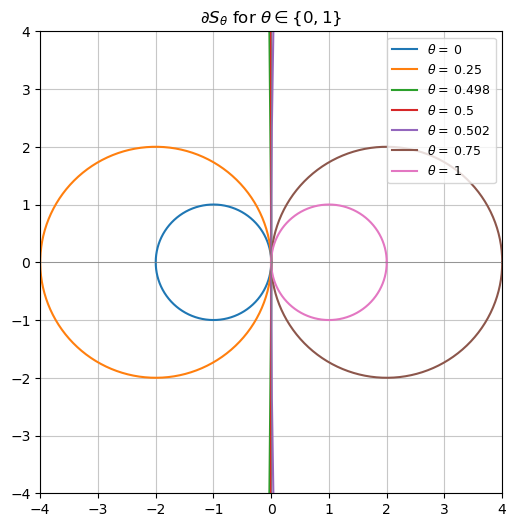

In [8]:
def abs_r(theta,phi):
    """
    Function parameterizing the absolute value of the boundary of the stability region,
    as a function of the complex argument.
    
    Parameters:
    -----------
        theta (float) : The theta parameter from the theta method.
        phi (ndarray) : 1D array with the complex argument we want to evaluate over.
    
    Returns:
    -----------
        r (ndarray) : 1D array of the absolute value of the boundary corresponding to the given phi values.
    """
    r = (2*np.cos(phi))/(2*theta-1)
    return r

phi = np.linspace(0,2*np.pi,1000)

plt.figure(figsize=(6,6))
for theta in theta_arr:
    # When theta = 0.5 we get a division by zero error, 
    # to avoid this we plot the effective graph of a circle with infinite raidus intersecting the origin
    if theta == .5:
        plt.plot(np.zeros(50),np.linspace(-4, 4) , label=r'$\theta =$ '+f'{theta}') 
        continue

    # Compute the modulus
    radius = np.clip(abs_r(theta, phi),0,1e10)

    # Convert to Cartesian coordinates
    x = radius * np.cos(phi)
    y = radius * np.sin(phi)

    # Plot
    plt.plot(x, y, label=r'$\theta =$ ' + f'{theta}')

plt.axhline(0, color='gray', lw=0.5)
plt.axvline(0, color='gray', lw=0.5)
plt.xlim(-4, 4)
plt.ylim(-4, 4)
plt.gca().set_aspect('equal')  # Ensure aspect ratio is 1:1
plt.legend(fontsize = 9, loc = 'upper right')
plt.title(r"$\partial S_\theta$ for $\theta \in \{0,1\}$")
plt.grid(alpha=0.7)
plt.show()

>**Computational task 3.1**

After Fourier transforming the equation, we use the $\theta$-method to calculate each new value for $U_{n+1}$. We have

\begin{align}
    \hat{U}_{n+1} &= \hat{U}_n + \tau\left(\theta F(t_{n+1},\hat{U}_{n+1}) + (1-\theta) F(t_n,\hat{U}_n)  \right)
\end{align}

where,

\begin{align}
    F(t_{n+1},\hat{U}_{n+1}) &= \partial_t\hat{U}_{n+1} =\hat{g}(X,Y,t_{n+1}) - \kappa\lvert\tilde{k}\rvert^4\hat{U}_{n+1} \\
    F(t_{n},\hat{U}_{n}) &= \partial_t\hat{U}_{n} = \hat{g}(X,Y,t_{n}) - \kappa\lvert\tilde{k}\rvert^4\hat{U}_{n}
\end{align}

Putting this into the equation gives us

\begin{align}
\hat{U}_{n+1} &= \hat{U}_n + \tau \left( \theta \left( \hat{g}(X,Y,t_{n+1}) - \kappa \lvert\tilde{k}\rvert^4 \hat{U}_{n+1} \right) + (1 - \theta) F(t_n, \hat{U}_n) \right) \\[4mm]
\Rightarrow \quad \hat{U}_{n+1} + \tau \theta \kappa \lvert\tilde{k}\rvert^4 \hat{U}_{n+1} &= \hat{U}_n + \tau \left( \theta \hat{g}(X,Y,t_{n+1}) + (1 - \theta) F(t_n, \hat{U}_n) \right) \\[4mm]
\Rightarrow \quad \hat{U}_{n+1} &= \frac{\hat{U}_n + \tau \left( \theta \hat{g}(X,Y,t_{n+1}) + (1 - \theta) F(t_n, \hat{U}_n) \right)}{1+\tau \theta \kappa \lvert\tilde{k}\rvert^4} \\[4mm]
\Rightarrow \quad \hat{U}_{n+1} &= \frac{\hat{U}_n + \tau \left( \theta \hat{g}(X,Y,t_{n+1}) + (1 - \theta) (\hat{g}(X,Y,t_{n}) - \kappa\lvert\tilde{k}\rvert^4\hat{U}_{n} )\right)}{1+\tau \theta \kappa \lvert\tilde{k}\rvert^4}
\end{align} 

where $\kappa \lvert\tilde{k}\rvert^4$ is the K\_op operator. We use this to calculate the value for $\hat{U}$ for each timestep, using the value of $\hat{U}$ for the previous timestep and yield each value to create a generator.  


In [9]:
def transient_biharmonic_solver(*, kappa,
                                   X, Y, U0,
                                   t0, T, Nt,
                                   theta=0.5,
                                   g=None):
    """
    Solve the transient biharmonic equation using the theta method.

    Parameters:
    ----------- 
        kappa (float)          : Diffusion coefficient.
        X (ndarray)            : 2D array of x-coordinates.
        Y (ndarray)            : 2D array of y-coordinates.
        U0 (ndarray)           : 2D array of the initial condition.
        t0 (float)             : Initial time.
        T (float)              : Final time.
        Nt (int)               : Number of time steps.
        g (callable, optional) : Source term function g(X, Y, t, kappa). Defaults to None.

    Yields:
    ----------- 
        U_hat, t (tuple) : A tuple containing the discrete Fourier transform of U at t, and the current time t.
    """
    
    # Makes g a callable fuction of X, Y, t and kappa, with all zeros as value to represent g(x, y, t) = 0
    if g is None:
        g = lambda X, Y, t, kappa: np.zeros_like(X)
        
    # Prepare relevant data for Fourier transform
    x, y  = X[:, 0], Y[0, :]
    Nx, Ny = X.shape
    dx, dy = (x[1]- x[0]), (y[1] - y[0])
    
    # Transforms the 2D space to a Fourier frequency space
    kx, ky = fftfreq(Nx, d=dx) * 2j * np.pi, fftfreq(Ny, d=dy) * 2j * np.pi
    KX, KY = np.meshgrid(kx, ky, indexing='ij', sparse=True)

    # Computing the biharmoic operator in Fourier space
    K_op = kappa*(KX**2 + KY**2)**2

    # Compute DFT of the initial value
    U_hat = fft2(U0)

    # Add your time-stepping loop here
    t  = t0
    dt = (T-t0)/Nt

    yield U_hat, t

    while t < T-dt/2:
        # Solve for next time step and update time
        g_hat_n = fft2(g(X, Y, t, kappa))
        g_hat_np1 = fft2(g(X, Y, t + dt, kappa))
        F_n = g_hat_n - U_hat * K_op

        U_hat = (U_hat + dt * ( theta * g_hat_np1 + (1-theta) * F_n )) / (1 + dt * theta * K_op)

        t += dt
        yield U_hat, t

In [10]:
def solve_for_lambda_and_convert(u_str):
    """
    Uses SymPy to solve the transient biharmonic equation (∂ₜu + κΔ²u = g) for a given string of the function u(x, y, t)
    and g = 0 to find the value of lambda, then substitute the value of lambda to be used for further calculations.
    Returns the function u(x, y, kappa) and value of lambda. Also prints them out to check for correct input and output.

    Parameters:
    ----------- 
        u_str (str) : String representation of the function u(x, y, t lambd, kappa).

    Returns:
    ----------- 
        u_ex (callable)         : NumPy-compatible function representing u(x, y, t kappa) (after substituting for lambda value).
        lambda_solution (float) : Value of lambda.
    """
    
    # Define symbolic variables
    x, y, t, kappa, lambd = sy.symbols('x y t kappa lambd')
    
    # Convert string to symbolic expression
    u_sy = eval(u_str)
    
    # Define operators
    biharmonic_op = lambda u: sy.diff(u, x, 4) + sy.diff(u, y, 4) + 2 * sy.diff(sy.diff(u, x, 2), y, 2)
    dt_u = lambda u: sy.diff(u, t, 1)

    # Solve for lambda
    equation = sy.Eq(dt_u(u_sy) + (kappa * biharmonic_op(u_sy)), 0)
    lambda_solution = sy.solve(equation, lambd)[0]  # Extract solution
    
    # Substitute lambda into u_sy
    u_sy_substituted = u_sy.subs(lambd, lambda_solution)
    
    # Print out the symbolic expressions for verification
    print(f'u = {u_sy_substituted}')
    
    # Convert to a NumPy function
    u_ex = sy.lambdify((x, y, t, kappa), u_sy_substituted, modules='numpy')

    return u_ex, lambda_solution

# Example usage
u_ex_str3 = "sin(x)*cos(y)*exp(-lambd*kappa*t)"
u_ex3, lambd_value = solve_for_lambda_and_convert(u_ex_str3)

print(f"Lambda = {lambd_value} for g(x,y,t) = 0")

u = exp(-4*kappa*t)*sin(x)*cos(y)
Lambda = 4 for g(x,y,t) = 0


>**Computational task 3.2**

In [11]:
def compute_EOC_Nt(*, kappa, X, Y, U0, t0, T, Nt_arr, u_ex, method, theta=None, g=None, coeff=None):
    """
    Compute errors and experimental order of convergence for a set of time steps (Nt) for the numerical methods:
    Spectral solver for the Transient Biharmonic equation     (SS_TB),
    IMEX backward Euler solver for the Cahn-Hilliard equation (IMEX_Euler_CH),
    IMEX Song scheme solver for the Cahn-Hilliard equation    (IMEX_Song_CH).

    Parameters:
    ----------- 
        kappa (float)            : Diffusion coefficient or the biharmonic operator.
        X (ndarray)              : 2D array of x-coordinates.
        Y (ndarray)              : 2D array of y-coordinates.
        U0 (ndarray)             : Initial condition array.
        t0 (float)               : Initial time.
        T (float)                : Final time.
        Nt_arr (ndarray)         : Number of time steps.
        u_ex (callable)          : Exact analytical function of u(x, y, t, kappa).
        method (string)          : Keyname for numerical method used for solution.
        theta (float, optional)  : Theta used for the theta method in transient_biharmonic_solver(). Defaults to None. 
        g (callable, optional)   : Source term function g(X, Y, t, kappa). Defaults to None.
        coeff (string, optional) : Keyname for coefficients used in IMEX_song_solver(). Defaults to None.

    Returns:
    ----------- 
        errors (ndarray) : 1D array of errors for each number of time steps Nt.
        EOCs (ndarray)   : 1D array of experimental order of convergence as a relation from previous time steps Nt.
    """
    
    errors_list = []

    # Loop over Nt values
    for i in range(len(Nt_arr)):
        errors_per_Nt_list =[]
        
        if method == "SS_TB": 
            # Spectral solver for the Transient Biharmonic equation
            solver = transient_biharmonic_solver(kappa=kappa, X=X, Y=Y, U0=U0, t0=t0, T=T, Nt=Nt_arr[i], theta=theta, g=g)
        
        elif method == "IMEX_Euler_CH": 
            # IMEX backward Euler solver for the Cahn-Hilliard equation (for task 4)
            solver = cahn_hilliard_backward_euler(kappa=kappa, X=X, Y=Y, U0=U0, t0=t0, T=T, Nt=Nt_arr[i], g=g, alpha=1.5)
        
        elif method == "IMEX_Song_CH": 
            # IMEX Song scheme solver for the Cahn-Hilliard equation (for task 5)
            solver = IMEX_song_solver(kappa=kappa, X=X, Y=Y, U0=U0, t0=t0, T=T, Nt=Nt_arr[i], g=g, alpha=1.5, coefficients=coefficients)
        
        else:
            # If incorrect keyname for method is given, raise error
            raise KeyError("Method input is not valid")

        for U_hat, t in solver:
            U_num = ifft2(U_hat).real
            U_ex  = u_ex(X, Y, t, kappa)
            errors_per_Nt_list.append(np.max(np.abs(U_num - U_ex)))
        
        # For error values where overflow occurs, 
        # we make sure to add the "nan" values as the largest error to show that the error is not computable
        if np.any(np.isnan(errors_per_Nt_list)):  # If nan is in the list, append nan as max error for that Nt.
            errors_list.append(np.nan)
        else:
            errors_list.append(max(errors_per_Nt_list))  

    errors = np.array(errors_list)

    # Compute EOC values
    d    = (T-t0)/Nt_arr
    EOCs = np.log(errors[1:]/errors[:-1])/np.log(d[1:]/d[:-1])

    return errors, EOCs

In [12]:
np.seterr(over='ignore', invalid='ignore') # Choose to ignore overflow warnings for aesthetical reasons :)

{'divide': 'warn', 'over': 'warn', 'under': 'ignore', 'invalid': 'warn'}

In [13]:
# Defines domain, parameters and initial condition
Lx, Ly = 2*np.pi, 2*np.pi
Nx, Ny = 20, 20
x, y   = np.linspace(-Lx/2, Lx/2, Nx, endpoint=False), np.linspace(-Ly/2, Ly/2, Ny, endpoint=False)
X, Y   = np.meshgrid(x, y, indexing='ij')
kappa  = 1
t0     = 0
T      = 1
U0     = u_ex3(X, Y, 0, kappa)

Nt_arr = np.array([10, 20, 40, 80, 160, 320, 640])

theta_arr = np.array([1, 0.5, 0])

for theta in theta_arr:
    errors3, EOCs3 = compute_EOC_Nt(kappa=kappa, X=X, Y=Y, U0=U0, t0=t0, T=T, Nt_arr=Nt_arr, u_ex=u_ex3, method="SS_TB", theta=theta)
    print(f"\nConvergence studies for u(x, y, t, kappa) = {u_ex_str3} for theta = {theta}:")
    plot_convergence(Nt_arr, "Nt", errors3, EOCs3)


Convergence studies for u(x, y, t, kappa) = sin(x)*cos(y)*exp(-lambd*kappa*t) for theta = 1.0:

Nt             Error                    EOC            
--------------------------------------------------
10             6.323727e-02             --             
20             3.399813e-02             0.8953         
40             1.766385e-02             0.9447         
80             9.010042e-03             0.9712         
160            4.551183e-03             0.9853         
320            2.287346e-03             0.9926         
640            1.146639e-03             0.9963         

Convergence studies for u(x, y, t, kappa) = sin(x)*cos(y)*exp(-lambd*kappa*t) for theta = 0.5:

Nt             Error                    EOC            
--------------------------------------------------
10             4.897916e-03             --             
20             1.231609e-03             1.9916         
40             3.068988e-04             2.0047         
80             7.666231e-05     

In our EOC study, we mostly observe the expected results discussed in the theoretical tasks. For $\theta = 1.0$ we get an EOC approximately $1$, which is consistent with the convergence order of the implicit Euler method. For $\theta = 0.5$ we observe an EOC around $2$, as expected for the Crank-Nicholson method. 
However, for $\theta = 0$ our results is not in line with our previous prediction of the explicit Euler method having convergence order of $1$. Some further investigation is therefore required.

In our theoretical part, we derived the expression

\begin{equation}
    r_\theta(z) = \frac{1+(1-\theta)z}{1-\theta z}
\end{equation}

for the stability function of the $\theta$-method, where the linear eigenvalue equation $\partial_tU=\lambda U$ were used. Employing this to the transient biharmonic equation in Fourier space we obtain,

\begin{align}
    \partial_t\hat{U} + &\kappa\lvert\tilde{k}\rvert^4\hat{U} = 0 \\
    \lambda\hat{U}&=-\kappa\lvert\tilde{k}\rvert^4\hat{U}\\
    \lambda&= -\kappa\lvert\tilde{k}\rvert^4
\end{align}

which yields the stability function,

\begin{align}
    r_\theta = \frac{1-(1-\theta)\kappa\lvert\tilde{k}\rvert^4\tau}{1+\theta\kappa\lvert\tilde{k}\rvert^4\tau}.
\end{align}

The Courant-Friedrichs-Lewy (CFL) condition is in general a condition for PDEs that relates the maximum timestep allowed in order to obtain convergence given a spatial step-size in our simulation grid. This is found by employing the convergence criteria, $\lvert r_\theta\rvert \leq 1$, to the stability function for the $\theta$-method of the transient biharmonic equation. 



We mainly want to investigate the case of $\theta = 0$, to build some understanding around why our previous error- and EOC calculations yield such terrible results for this simulation. Note that we are working in Fourier space while solving the equation, so our CFL condition will relate the maximum frequency in Fourier space to the time-step, rather then the spacial step-size. Doing this, we see that

\begin{align}
    \lvert r_0\rvert =  \ \lvert1-\kappa\lvert\tilde{k}\rvert^4_{max}\tau\rvert &\leq 1\\
    -1\leq \ 1-\kappa\lvert\tilde{k}\rvert^4_{max}\tau &\leq 1  \\
    1-\kappa\lvert\tilde{k}\rvert^4_{max}\tau &\geq -1 \\
    \kappa\lvert\tilde{k}\rvert^4_{max}\tau &\leq 2
\end{align}

\begin{align}
    \implies \ \ \tau &\leq\frac{2}{\kappa\lvert\tilde{k}\rvert^4_{max}}\\
    \tau_{CFL} &= \frac{2}{\kappa\lvert\tilde{k}\rvert^4_{max}}.
\end{align}

And thus, by the relation $N = \frac{T}{\tau}$, we get

\begin{equation}
    N_{CFL} = \frac{T}{\tau_{CFL}} = \frac{T\kappa\lvert\tilde{k}\rvert^4_{max}}{2} \\[4mm]
\end{equation}


To avoid lots of unnecessary prints in our submitted code, we chose to omit the lines of code calculating $N_{CFL}$, but in a test run we implemented the following line in the transient biharmonic solver function, $N\_cfl = T*np.real(np.max(K\_op))/2$, which returned that $N_{CFL} = 20000$ for for $\theta = 0$. Since the time-steps used in our EOC analysis earlier where in the $10$ to $640$ range, this explains why we didn't see any error-convergence for $\theta = 0$. The time-steps simply weren't small enough. 

In [14]:
N_CFL     = 20000 # Calculated N_CFL value
N_CFL_arr = np.array([int(0.5*N_CFL), N_CFL, 2*N_CFL, 4*N_CFL])

theta = 0

errors3, EOCs3 = compute_EOC_Nt(kappa=kappa, X=X, Y=Y, U0=U0, t0=t0, T=T, Nt_arr=N_CFL_arr, u_ex=u_ex3, method="SS_TB", theta=theta)
print(f"\nConvergence studies for u(x, y, t, kappa) = {u_ex_str3} for theta = {theta}:")
plot_convergence(N_CFL_arr, "Nt = N_CFL", errors3, EOCs3)


Convergence studies for u(x, y, t, kappa) = sin(x)*cos(y)*exp(-lambd*kappa*t) for theta = 0:

Nt = N_CFL     Error                    EOC            
--------------------------------------------------
10000          nan                      --             
20000          3.679101e-05             nan            
40000          1.839474e-05             1.0001         
80000          9.197178e-06             1.0000         


As we see, when we reach $N_t =  N_{CFL}$  our error dramatically decrease, and we obtain the expected convergence order of 1 for the explicit Euler method.

>**Computational task 3.3**

In [15]:
def transient_biharmonic_solver_sym(u_str):
    """
    Uses SymPy to solve the transient biharmonic equation (∂ₜu + κΔ²u = g) for a given string of the function u(x, y, t).
    To find the right hand side function g(x, y, t). Also prints them out to check for correct input and output.

    Parameters:
    ----------- 
        u_str (str) : String representation of the function u(x, y, t, kappa).

    Returns:
    ----------- 
        u (callable) : NumPy-compatible function representing u(x, y, t, kappa).
        g (callable) : NumPy-compatible function representing g(x, y, t, kappa).
    """

    x, y, t, kappa = sy.symbols('x y t kappa') # Define symbolic variables x and y
    u_sy = eval(u_str)       # Convert the input string representation of u into a SymPy expression

    # Solves the equation with SymPy functions
    biharmonic_op = lambda u: sy.diff(u, x, 4) + sy.diff(u, y, 4) + 2 * sy.diff(sy.diff(u, x, 2), y, 2)
    dt_u          = lambda u: sy.diff(u, t, 1)

    g_sy = sy.simplify(sy.diff(u_sy, t, 1) + kappa*biharmonic_op(u_sy))

    # Print out the symbolic expressions for verification
    print(f'u = {u_sy}')
    print(f'g = {g_sy}')

    # Convert symbolic expressions into NumPy-compatible functions
    u = sy.lambdify((x, y, t, kappa), u_sy, modules='numpy')
    g = sy.lambdify((x, y, t, kappa), g_sy, modules='numpy')

    return u, g

u_ex_str3 = '( exp (1 + sin(x) * sin(x)) + exp(1 + cos(y) * cos(y))) * exp(-4 * kappa * t)'
u_ex3, g3 = transient_biharmonic_solver_sym(u_ex_str3)

u = (exp(sin(x)**2 + 1) + exp(cos(y)**2 + 1))*exp(-4*kappa*t)
g = 4*kappa*((4*sin(x)**8 + 16*sin(x)**6 - 4*sin(x)**4 - 12*sin(x)**2 + 1)*exp(sin(x)**2 + 1) + (4*sin(y)**8 - 32*sin(y)**6 + 68*sin(y)**4 - 44*sin(y)**2 + 5)*exp(cos(y)**2 + 1) - exp(sin(x)**2 + 1) - exp(cos(y)**2 + 1))*exp(-4*kappa*t)


In [16]:
U0 = u_ex3(X, Y, 0, kappa)

theta_arr = np.array([1, 0.5])

for theta in theta_arr:
    errors3, EOCs3 = compute_EOC_Nt(kappa=kappa, X=X, Y=Y, U0=U0, t0=t0, T=T, Nt_arr=Nt_arr, u_ex=u_ex3, method="SS_TB", theta=theta, g=g3)
    print(f"\nConvergence studies for u(x, y, t, kappa) = {u_ex_str3} for theta = {theta}:")
    plot_convergence(Nt_arr, "Nt", errors3, EOCs3)


Convergence studies for u(x, y, t, kappa) = ( exp (1 + sin(x) * sin(x)) + exp(1 + cos(y) * cos(y))) * exp(-4 * kappa * t) for theta = 1.0:

Nt             Error                    EOC            
--------------------------------------------------
10             1.754152e+00             --             
20             9.077591e-01             0.9504         
40             4.615883e-01             0.9757         
80             2.327246e-01             0.9880         
160            1.168455e-01             0.9940         
320            5.854387e-02             0.9970         
640            2.930253e-02             0.9985         

Convergence studies for u(x, y, t, kappa) = ( exp (1 + sin(x) * sin(x)) + exp(1 + cos(y) * cos(y))) * exp(-4 * kappa * t) for theta = 0.5:

Nt             Error                    EOC            
--------------------------------------------------
10             1.248108e-01             --             
20             3.128378e-02             1.9963         


Also for this manufactured solution, we observe the expected convergence orders.

## Task 4

>**Task 4.1**

Using the given IMEX scheme for the Cahn-Hilliard equation with constant mobility $M = 1$ from the theoretical introduction to this task, but with the slight alteration of adding an implicit evaluation of $g$ at the right hand side, i.e.,

\begin{equation}
    \frac{u_{n+1}-u_{n}}{\tau} + \kappa\Delta^2u_{n+1} - a\Delta u_{n+1} = \Delta\left((u_n)^3-(1+a)u_n\right) + g_{n+1}
\end{equation}

rewriting this equation to the form $U_{n+1} + \tau\mathbf{L}U_{n+1} = U_n + \tau\{\mathbf{N}(U_n) + g_{n+1}\}$, we get

\begin{equation}
    u_{n+1} + \tau\{\kappa\Delta^2 -a\Delta\}u_{n+1} = u_n+\tau\{\Delta\left((u_n)^3-(1+a)u_n\right) + g_{n+1}\}.
\end{equation}

Here, our non-linear term and linear operator becomes

\begin{align}
    \mathbf{N}(u_n) &= \Delta\left((u_n)^3-(1+a)u_n\right)\\
    \mathbf{L} &= \{\kappa\Delta^2 -a\Delta\}
\end{align}

and our IMEX scheme can be neatly rewritten as

\begin{equation}
    u_{n+1}+\tau \mathbf{L}u_{n+1} = u_n + \tau\{\mathbf{N}(u_n) + g_{n+1}\}
\end{equation}

Transforming this equation to Fourier-space, we obtain 

\begin{align}
    (1+\tau\hat{\mathbf{L}})\hat{u}_{n+1} &= \hat{u}_n + \tau\{\widehat{\mathbf{N}(u_n)} +\hat{g}_{n+1}\} \\
    \hat{u}_{n+1} &= \frac{1}{(1+\tau\hat{\mathbf{L}})}\left(\hat{u}_n + \tau\{\widehat{\mathbf{N}(u_n)} +\hat{g}_{n+1}\}\right)
\end{align}

where the linear operator in Fourier space becomes

\begin{equation}
    \hat{\mathbf{L}} = \{\kappa\lvert\tilde{k}\rvert^4 + a\lvert\tilde{k}\rvert^2\}
\end{equation}

So to solve for the next timestep, we need to calculate the non-linear term in Fourier space. Since the product of functions becomes a convolution in Fourier space, we will use the inverse Fourier transform to calculate the non-linear term in cartesian space, and transform the solution of this calculation back to Fourier space in order to find the solution at the next timestep. 
The transformation scheme for calculating the non-linear term goes as follows,

\begin{equation}
    \hat{u}_n \rightarrow u_n \rightarrow f(u_n) \rightarrow \widehat{f(u_n)}\rightarrow\widehat{\mathbf{N}(u_n)}
\end{equation}

where going from $\hat{f}$ to $\hat{\mathbf{N}}$ we apply the Laplace operator in Fourier space.

>**Task 4.2**

In [17]:
def cahn_hilliard_backward_euler(*, kappa, X, Y, U0, t0, T, Nt, g = None, alpha=1.5):
    """
    Implements the Cahn-Hilliard equation solver using the backward Euler method
    with a convex-concave splitting approach.

    Parameters:
    ----------- 
        kappa (float)           : Diffusion coefficient for the biharmonic operator.
        X (ndarray)             : 2D array representing the x-coordinates of the grid.
        Y (ndarray)             : 2D array representing the y-coordinates of the grid.
        U0 (ndarray)            : 2D array of the initial condition.
        t0 (float)              : Initial time.
        T (float)               : Final time.
        Nt (int)                : Number of time steps.
        g (callable, optinal)   : Source term as a function of g(X, Y, t, kappa). Defaults to None.
        alpha (float, optional) : Convex-concave splitting parameter. Defaults to 1.5.

    Yields:
    ----------- 
        U_hat, t (tuple) : A tuple containing the discrete Fourier transform of U at t, and the current time t.
    """
    
    # Makes g a callable fuction of X, Y, t and kappa, with all zeros as value to represent g(x, y, t) = 0
    if g is None:
        g = lambda X, Y, t, kappa : np.zeros_like(X)

    # Prepare relevant data for Fourier transform
    x, y   = X[:, 0], Y[0, :]
    Nx, Ny = X.shape
    dx, dy = (x[1]- x[0]), (y[1] - y[0])

    kx, ky = fftfreq(Nx, d=dx) * 2j * np.pi, fftfreq(Ny, d=dy) * 2j * np.pi
    KX, KY = np.meshgrid(kx, ky, indexing='ij', sparse=True)


    # Computing the laplace operator in Fourier space
    laplace = (KX**2 + KY**2)

    # Computing the linear operator for the Cahn-Hilliard equation
    L_hat   = kappa*(laplace)**2 - alpha*laplace

    # Computing the non-linear term as a function of the initial value in the fourier space
    N_hat = laplace*fft2((U0)**3 - (1+alpha)*U0)

    # Compute DFT of the initial value
    U_hat = fft2(U0)

    t  = t0
    dt = (T-t0)/Nt

    yield U_hat, t

    # Looping through the timesteps
    while t < T-(dt/2):

        # Solve for next time step
        g_hat_np1 = fft2(g(X, Y, t + dt, kappa))
        U_hat_np1 = (1/(1+dt*L_hat))*( U_hat + dt*(N_hat + g_hat_np1))

        # Updating the non-linear term
        U_hat = U_hat_np1
        U     = ifft2(U_hat).real

        N_hat = laplace*fft2((U)**3 - (1+alpha)*U)

        t += dt
        yield U_hat, t

In [18]:
def cahn_hilliard_be_solver_sym(u_str):
    """
    Uses SymPy to solve the Cahn-Hilliard equation for a given string of the function u(x, y, t).
    Returns the function u(x, y, t) and g(x, y, t) as NumPy functions.
    Also prints them out to check for correct input and output.

    Parameters:
    ----------- 
        u_str (str)   : String representation of the function u(x, y, t, kappa).
        kappa (float) : Constant coefficient in the biharmonic equation.

    Returns:
    ----------- 
        u (function)  : NumPy-compatible function representing u(x, y, t, kappa).
        g (function)  : NumPy-compatible function representing g(x, y, t, kappa).
    """

    x, y, t, kappa = sy.symbols('x y t kappa') # Define symbolic variables x, y, t and kappa
    u_sy = eval(u_str)                         # Convert the input string representation of u into a SymPy expression

    # Defining the operators in Fourier space
    laplace_op    = lambda u: sy.diff(u, x, 2) + sy.diff(u, y, 2)
    biharmonic_op = lambda u: sy.diff(u, x, 4) + sy.diff(u, y, 4) + 2 * sy.diff(sy.diff(u, x, 2), y, 2)

    g_sy = sy.simplify(sy.diff(u_sy, t, 1) + kappa*biharmonic_op(u_sy) - laplace_op(u_sy**3 -u_sy))

    # Print out the symbolic expressions for verification
    print(f'u = {u_sy}')
    print(f'g = {g_sy}')

    # Convert symbolic expressions into NumPy-compatible functions
    u = sy.lambdify((x, y, t, kappa), u_sy, modules='numpy')
    g = sy.lambdify((x, y, t, kappa), g_sy, modules='numpy')

    return u, g


u_ex_str4 = 'sin(x)*cos(y)*exp(-4*kappa*t)'
u_ex4, g4 = cahn_hilliard_be_solver_sym(u_ex_str4)

u = exp(-4*kappa*t)*sin(x)*cos(y)
g = 2*(-exp(8*kappa*t) - 9*sin(x)**2*sin(y)**2 + 6*sin(x)**2 + 3*sin(y)**2 - 3)*exp(-12*kappa*t)*sin(x)*cos(y)


>**Task 4.3**

In [19]:
# Defines domain, parameters and initial condition
Lx, Ly = 16*np.pi, 16*np.pi
Nx, Ny = 64, 64
x, y   = np.linspace(0, Lx, Nx, endpoint=False), np.linspace(0, Ly, Ny, endpoint=False)
X, Y   = np.meshgrid(x, y, indexing='ij')
t0     = 0
T      = 1
U0     = u_ex4(X, Y, 0, kappa)

Nt_arr = np.array([100, 200, 400, 800, 1600, 3200])

kappa_arr = np.array([1, 0.01])

# Plots error and eoc for different values of kappa and Nt
for kappa in kappa_arr:
    errors4, EOCs4 = compute_EOC_Nt(kappa=kappa, X=X, Y=Y, U0=U0, t0=t0, T=T, Nt_arr=Nt_arr, u_ex=u_ex4, method="IMEX_Euler_CH", g=g4)
    print(f"\nConvergence studies for u(x, y, t, kappa) = {u_ex_str4} for kappa = {kappa}:")
    plot_convergence(Nt_arr, "Nt", errors4, EOCs4)


Convergence studies for u(x, y, t, kappa) = sin(x)*cos(y)*exp(-4*kappa*t) for kappa = 1.0:

Nt             Error                    EOC            
--------------------------------------------------
100            2.468441e-02             --             
200            1.257610e-02             0.9729         
400            6.348352e-03             0.9862         
800            3.189490e-03             0.9931         
1600           1.598604e-03             0.9965         
3200           8.002707e-04             0.9983         

Convergence studies for u(x, y, t, kappa) = sin(x)*cos(y)*exp(-4*kappa*t) for kappa = 0.01:

Nt             Error                    EOC            
--------------------------------------------------
100            3.155154e-03             --             
200            1.740620e-03             0.8581         
400            9.181071e-04             0.9229         
800            4.720693e-04             0.9597         
1600           2.394364e-04            

In our convergence study, we observe a general order of convergence of approximately 1 for both values of $\kappa$, which confirms our method is of first order in time. 

Furthermore, the magnitude of the error is larger for $\kappa = 1$ then $\kappa = 0.01$. This is because larger $\kappa$ makes the time dependent decrease more rapid, and you thus need a finer grid to capture the rapid change, resulting in a larger error for the same $N_t$ and a larger $\kappa$

## Task 5

>**Theoretical task 5.1**

We consider the equation

\begin{align}
    U_t = -\mathbf{L}U + \mathbf{N}(U), \qquad U(t_0) = U_0.
\end{align}

with the numerical scheme

\begin{align}
U^{(1)} &= U^n + \tau \left( \mathbf{L} U^{(1)} + \mathbf{N}(U^n) \right), \\
U^{(2)} &= \alpha_{10} U^n + \alpha_{11} U^{(1)} + \beta_1 \tau \left( \mathbf{L} U^{(2)} + \mathbf{N}(U^{(1)}) \right), \\
U^{n+1} &= \alpha_{20} U^n + \alpha_{21} U^{(1)} + \alpha_{22} U^{(2)} + \beta_2 \tau \left( \mathbf{L} U^{n+1} + \mathbf{N}(U^{(2)}) \right)
\end{align}

the Taylor expansion of the exact solution is,

\begin{align}
    U(t_0 + \tau) = U(t_0) + U'(t_0)\tau + \frac{1}{2}U''(t_0)\tau^2 + \mathcal{O}(\tau^3),
\end{align}

where

\begin{align}
    U'(t_0) = -\mathbf{L} U_0 + \mathbf{N}(U_0),
    \quad U''(t_0) = U'(t_0)\left(\mathbf{N}'(U_0)-\mathbf{L}\right).
\end{align}

The local truncation error is

\begin{align}
    \eta = U(t_0 + \tau) - U^{n+1}.    
\end{align}

Inserting the Taylor expansion and the full form of the numerical update to get:

\begin{align}
&\eta = \left[ U_0 + \tau U'(t_0) + \frac{\tau^2}{2} U''(t_0) + \mathcal{O}(\tau^3) \right] \\
- &\left[ \alpha_{20} U_0 + \alpha_{21} U^{(1)} + \alpha_{22} U^{(2)} + \beta_2 \tau (\mathbf{L} U^{n+1} + \mathbf{N}(U^{(2)})) \right].
\end{align} 

The method is consistent of order $( p = 2 )$ if and only if

\begin{align}
    \eta \leq D \tau^{p + 1} = D \tau^3 \quad \text{for some } D > 0,
\end{align}

which means that $\eta$ have to be of order 3 or higher and the coefficients must therefore be determined so that the the other terms are canceled out. $U^{(1)}$ and $U^{(2)}$ can be used in the expression of $\eta$ as well as the expressions of $U'(t_0)$ and $U''(t_0)$. Furthermore, we get

\begin{align*}
\eta =\ & \left[ U_0 + \tau \left( -\mathbf{L} U_0 + \mathbf{N}(U_0) \right)
+ \frac{\tau^2}{2} \left( U'(t_0) (\mathbf{N}'(U_0) - \mathbf{L}) \right)
+ \mathcal{O}(\tau^3) \right] - \left( \alpha_{20} U^0 
+ \alpha_{21} \left( U^0 + \tau \left( \mathbf{L} U^{(1)} + \mathbf{N}(U^0) \right) \right) \right. \\[4mm]
\quad\quad &- \alpha_{22} \left( \alpha_{10} U^0 + \alpha_{11} U^{(1)} 
+ \beta_1 \tau \left( \mathbf{L} U^{(2)} + \mathbf{N}(U^{1}) \right) \right) - \left(\beta_2 \tau (L U^{n+1} + \mathbf{N}(U^{(2)}))\right)
\end{align*}

and if you keep going like that, which will not be prioritized this time, you should end up with terms where the order conditions cancel out all terms with $\tau$ of order 2 and lower which shows that the scheme has consistency order $p=2$.

>**Theoretical task 5.2**

This numerical scheme is happening in the Fourier space where expressions for $\hat{U}^{(1)}$, $\hat{U}^{(2)}$, and $\hat{U}^{n+1}$ are retrieved from the given equations. The operators $\hat{L}$ and $\hat{N}(U)$ are almost the same as in task 4. However, because
$U_t = \mathbf{L}U + \mathbf{N}(U)$, 
the sign in the $\mathbf{\hat{L}}$ operator differs from the previous task. We get

\begin{align}
    \\[4mm]
    U_t &= \mathbf{L}U + \mathbf{N}(U) \\
    \Rightarrow \frac{U_{n+1}-U_n}{\tau}&=\mathbf{L}U_{n+1} + \mathbf{N}(U_n) \\
    \Rightarrow U^{n+1} + \tau (-\mathbf{L}) U^{n+1} &= U^n + \tau \mathbf{N}(U^n).
    \\[4mm]
\end{align} 

which is the same equation used to find $\mathbf{L}$ in the Cahn-Hilliard equation, but this time with a negative sign in front of $\mathbf{L}$. Therefore, we obtain 

\begin{align}
    \\[6mm]
    \mathbf{\hat{L}} &= -\{\kappa\Delta^2-a\Delta\} \\
    \mathbf{\hat{N}}(\hat{U_n}) &= \Delta\left((\hat{U_n})^3-(1+a)\hat{U_n}\right)
    \\[6mm]
\end{align} 

where $\mathbf{\hat{N}}(\hat{U_n})$ is the non-liner term in Fourier space. In the implementation, we inversely transform $\hat{U}$ to the cartesian space and then return $-\kappa\lvert\tilde{k}\rvert^2\mathcal{F}[f(U)]$  where $f(u) = U^3 - (1 + a) U$ and $-\lvert\tilde{k}\rvert^2$ is the Laplace operator in Fourier space. This is done to avoid the convolution from the transformation of $U^3$ just as in the previous task. However, the operator is used in each of the steps in the numerical scheme, with different input values, and is therefore implemented as a function of its own. Further, we have 

\begin{align}
\\[6mm]
\hat{\mathbf{G}}^{n+1/2} &= \mathcal{F}[g(X, Y, t_0 + \tfrac{\tau}{2})]
\\[6mm]
\end{align} 

\begin{align}
\hat{U}^{(1)} &= \hat{U}^n + \tau \left( \mathbf{L} \hat{U}^{(1)} + \mathbf{N}(\hat{U}^n) +\mathbf{G}^{n+1/2}\right) \\[2ex]
\Rightarrow \hat{U}^{(1)} &= \frac{\hat{U}^n +\tau \left( \mathbf{N}(\hat{U}^n) + \hat{\mathbf{G}}^{n+1/2} \right)}{1 - \tau \mathbf{L}} \\[2ex]
\hat{U}^{(2)} &= \alpha_{10} \hat{U}^n + \alpha_{11} \hat{U}^{(1)} + \beta_1 \tau \left( \mathbf{L} \hat{U}^{(2)} + \mathbf{N}(\hat{U}^{(1)}) + \hat{\mathbf{G}}^{n+1/2} \right) \\[2ex]
\Rightarrow \hat{U}^{(2)} &= \frac{\alpha_{10} \hat{U}^n + \alpha_{11} \hat{U}^{(1)} + \beta_1 \tau \left(\mathbf{N}(\hat{U}^{(1)}) + \hat{\mathbf{G}}^{n+1/2} \right)}{1-\beta_1\mathbf{L}\tau} \\[2ex]
\hat{U}^{n+1} &= \alpha_{20} \hat{U}^n + \alpha_{21} \hat{U}^{(1)} + \alpha_{22} \hat{U}^{(2)} + \beta_2 \tau \left( \mathbf{L} \hat{U}^{n+1} + \mathbf{N}(\hat{U}^{(2)}) \right) \\[2ex]
\Rightarrow \hat{U}^{n+1} &= \frac{\alpha_{20} \hat{U}^n + \alpha_{21} \hat{U}^{(1)} + \alpha_{22} \hat{U}^{(2)} + \beta_2 \tau \left( \mathbf{L} \hat{U}^{n+1} + \mathbf{N}(\hat{U}^{(2)}) \right)}{1-\beta_2 \tau \mathbf{L}}
\end{align}

which is the numerical scheme used in the IMEX\_song\_solver function.

>**Computational task 5.3**

In [20]:
def N_hat_func(U, laplace, alpha):
    '''
    Function for calculating N_hat(U) in the numerical scheme in the IMEX_song_solver.

    Parameters:
    ----------- 
      U (2D ndarray)     : containing values for U in the fourier space at a given time
      laplace (operator) : laplace operator in the Fourier room
      alpha (float)      : convex-concave splitting parameter

    Returns:
    ----------- 
      (2D ndarray)       : containing values for N_hat(U) in the fourier space at a given time

    '''

    U = ifft2(U).real
    return laplace * fft2(U**3 - (1+alpha)*U)

def IMEX_song_solver(*, kappa, X, Y, U0, t0, T, Nt, g = None, alpha=1.5, coefficients):
    """
    Function for solving the Cahn-Hilliard equation using the Song (IMEX) scheme.

    Parameters:
    ----------- 
        kappa (float)           : Diffusion coefficient for the biharmonic operator.
        X (ndarray)             : 2D array representing the x-coordinates of the grid.
        Y (ndarray)             : 2D array representing the y-coordinates of the grid.
        U0 (ndarray)            : 2D array of the initial condition.
        t0 (float)              : Initial time.
        T (float)               : Final time.
        Nt (int)                : Number of time steps.
        g (callable, optinal)   : Source term as a function of g(X, Y, t, kappa). Defaults to None.
        alpha (float, optional) : Convex-concave splitting parameter. Defaults to 1.5.
        coefficients (string)   : Coefficient set used for a10, a11, a20, a21, a22, beta1 and beta2.

    Yields:
    ----------- 
        U_hat, t (tuple) : A tuple containing the discrete Fourier transform of U at t, and the current time t.
    """
    
    # Makes g a callable fuction of X, Y, t and kappa, with all zeros as value to represent g(x, y, t) = 0
    if g is None:
        g = lambda X, Y, t, kappa : np.zeros_like(X) # Sets g(X,Y,t) to a 2D array with zeros if the equation is homogenous

    # Dictionary for the different coefficents
    coeff_dict = {
        "c1": (3/2, -1/2, 0, 0, 1, 1/2, 1),
        "c2": (2, -1, 1/2, 0, 1/2, 1, 1),
        "c3": (2, -1, 0, 1/2, 1/2, 1, 1/2),
        "c4": (5/2, -3/2, 2/3, 0, 1/3, 3/2, 1)
    }

    try:
        a10, a11, a20, a21, a22, beta1, beta2 = coeff_dict[coefficients]
    except KeyError:
        # Raises error if coefficent input is wrong 
        raise ValueError(f"Uknown choice of coefficients: {coefficients}. Choose among {list(coeff_dict)}")
    
    # Prepare relevant data for Fourier transform
    x, y   = X[:, 0], Y[0, :]
    Nx, Ny = X.shape
    dx, dy = (x[1]- x[0]), (y[1] - y[0])
    
    # Transforms the 2D space to a Fourier frequency space
    kx, ky = fftfreq(Nx, d=dx) * 2j * np.pi, fftfreq(Ny, d=dy) * 2j * np.pi
    KX, KY = np.meshgrid(kx, ky, indexing='ij', sparse=True)
    
    # Computing the laplace operator in Fourier space
    laplace = (KX**2 + KY**2)

    # Computing the linear operator for the Cahn-Hilliard equation
    L_hat   = - (kappa*(laplace)**2 - alpha*laplace)

    # Making it easier to use the N_hat function without having to write the value of laplace and alpha every time
    N_hat = lambda U: N_hat_func(U, laplace, alpha)

    # Compute DFT of the initial value
    U_hat = fft2(U0)

    # Initial value for t and step size
    t  = t0
    dt = (T-t0)/Nt

    # Computing the fourier transform of g(X,Y,t0 + dt/2) and g(X,Y,t0 + dt) as required in the numerical scheme
    G_hat = fft2(g(X, Y , t0 + dt/2, kappa))

    # Numerical scheme
    U1    = (U_hat + dt*(N_hat(U_hat) + G_hat)) / (1 - dt*L_hat)
    U2    = (a10*U_hat + a11*U1 + beta1*dt*(N_hat(U1) + G_hat)) / (1 - beta1*dt*L_hat)
    U_hat = (a20*U_hat + a21*U1 + a22*U2 + beta2*dt*(N_hat(U2) + G_hat)) / (1 - beta2*dt*L_hat)

    t += dt # Setting the right time step for when the loop starts

    # Yields first value of U_hat and the time
    yield U_hat, t

    # Looping through the timesteps doing the numerical scheme as explained in the text
    while t < T-(dt/2):
        G_hat = fft2(g(X, Y, t + dt/2,kappa))

        U1 = ( U_hat + dt * (N_hat(U_hat) + G_hat) ) / (1 - dt * L_hat)
        U2 = (a10 * U_hat + a11 * U1 + beta1 * dt*(N_hat(U1) + G_hat)) / (1 - beta1 * dt * L_hat)
        U_hat = (a20 * U_hat + a21 * U1 + a22 * U2 + beta2 * dt * (N_hat(U2) + G_hat)) / (1 - beta2 * dt * L_hat)

        t += dt
        yield U_hat, t

In [21]:
# Defines kappa and initial condition
kappa = 0.01
U0    = u_ex4(X, Y, 0, kappa)

Nt_arr = np.array([100, 200, 400, 800, 1600])

coeff_list = ["c1", "c2", "c3", "c4"]

# Plots the error and EOC for different values of Nt for the different sets of coefficients
for coefficients in coeff_list:
    errors5, EOCs5 = compute_EOC_Nt(kappa=kappa, X=X, Y=Y, U0=U0, t0=t0, T=T, Nt_arr=Nt_arr, u_ex=u_ex4, method="IMEX_Song_CH", g=g4, coeff=coefficients)
    print(f"\nConvergence studies for u(x, y, t, kappa) = {u_ex_str4} for coefficients {coefficients}:")
    plot_convergence(Nt_arr, "Nt", errors5, EOCs5)


Convergence studies for u(x, y, t, kappa) = sin(x)*cos(y)*exp(-4*kappa*t) for coefficients c1:

Nt             Error                    EOC            
--------------------------------------------------
100            8.369471e-05             --             
200            2.156788e-05             1.9563         
400            5.405848e-06             1.9963         
800            1.346361e-06             2.0055         
1600           3.354146e-07             2.0050         

Convergence studies for u(x, y, t, kappa) = sin(x)*cos(y)*exp(-4*kappa*t) for coefficients c2:

Nt             Error                    EOC            
--------------------------------------------------
100            1.999943e-05             --             
200            8.931375e-06             1.1630         
400            2.951140e-06             1.5976         
800            8.428572e-07             1.8079         
1600           2.249610e-07             1.9056         

Convergence studies for u(x, y,

We notice that the IMEX\_song\_solver give an error with dimension between $10^{-5}$ and $10^{-7}$ except one error for the last set of coefficients where $N_t=100$ and the error is $1.154681\cdot10^{-4}$. For comparison, the cahn\_hilliard\_backward\_euler has errors with dimension between $10^{-2}$ and $10^{-4}$. The EOC study however, has better numbers for the cahn\_hilliard\_backward\_euler, but this is not really relevant when comparing the two different methods, as the EOC study is based on how the results differs for different values of $N_t$ for one method. 

The coefficients that gave the least error is 

\begin{align}
\alpha_{10} = 2,  \alpha_{11} = -1,  \alpha_{20} = \frac{1}{2},  \alpha_{21} = 0, \alpha_{22} = \frac{1}{2},  \beta_1 = 1,  \beta_2 = 1 \\[4mm]
\end{align}

and is therefore our favorite and will be used later on in the next task. 

## Task 6

To calculate the total mass $\int_\Omega u \ dx$, we simply calculate the sum over the whole $U$ mesh grid for each timestep.

From the exercise sheet we know that the interface energy is defined as
\begin{equation}
\mathcal{E}_{\text{int}}(u) = \int_{\Omega} \frac{\kappa}{2} |\nabla u|^2 \, dx.
\end{equation}
To calculate the square of the gradient of $u$, we calculate the gradient's x and y components separately in the Fourier space, by multiplying the respective $K$ meshgrid in each spatial direction. Then we sum the squares of the gradient components to find the modulo of the gradient squared, and sum over the whole resulting meshgrid and multiply by $\frac{\kappa}{2}$.

To calculate the mixing energy,
\begin{equation}
\mathcal{E}_{\text{mix}}(u) = \int_{\Omega} F(u) \, dx,
\end{equation}
we use the function $F(u) = \frac{1}{4}(u^2-1)^2$, and take the sum over the whole meshgrid. 

In [22]:
def calc_interface_energy(U_hat, kappa, X, Y):
    """
    Function for calculating the interface energy for a given concentration state.

    Parameters
    ----------- 
        U_hat (float)  : value for U in the fourier space at a given time and coordinates
        kappa (float)  : Diffusion coefficient for the biharmonic operator.
        X (float)      : x-coordinate
        Y (float)      : y-coordinate

    Returns
    ----------- 
        int_en (float) : interface energy
    """

    # Prepare relevant data for Fourier transform
    x, y   = X[:, 0], Y[0, :]
    Nx, Ny = X.shape
    dx, dy = (x[1] - x[0]), (y[1] - y[0])

    # Transforms the 2D space to a Fourier frequency space
    kx, ky = fftfreq(Nx, d=dx)*2j*np.pi, fftfreq(Ny, d=dy)*2j*np.pi
    KX, KY = np.meshgrid(kx, ky, indexing='ij', sparse=True)

    # Calculating the gradient in each spatial direction
    grad_x = ifft2(KX*U_hat).real
    grad_y = ifft2(KY*U_hat).real

    # Calculating interface energy
    int_en = (kappa/2)*np.sum( grad_x**2 + grad_y**2 )
    return int_en


def calc_mixing_energy(U):
    """
    Function for calculating the mixing energy for a given state

    Parameters
    ----------- 
        U (float)  : value for U 

    Returns
    ----------- 
        mix_en (float) : mixing energy for U

    """
    F      = lambda U : (1/4)*(U**2 - 1)**2
    mix_en = np.sum(F(U))
    return mix_en

In [23]:
def cahn_hilliard_energy_mass_plotter(T, dt, U0, solver, plot_mass=False):
    
    Nt = int((T-t0)//dt) # Defines number of time steps
    
    # Chooses solver from task 4 or 5
    if solver == "IMEX_Euler_CH":
        solver6 = cahn_hilliard_backward_euler(kappa=kappa, X=X, Y=Y, U0=U0, t0=t0, T=T, Nt=Nt, g = None, alpha=1.5)
    elif solver == "IMEX_Song_CH":
        solver6 = IMEX_song_solver(kappa=kappa, X=X, Y=Y, U0=U0, t0=t0, T=T, Nt=Nt, g = None, alpha = 1.5, coefficients= 'c2')
    
    # Lists for storing the results of the simulation
    t_arr            = []
    total_mass       = []
    mixing_energy    = []
    interface_energy = []
    total_energy     = []

    # Looping through the generator
    for U_hat, t in solver6:
        
        # Transforming U_hat to the real room
        U = ifft2(U_hat).real
        

        # Calculating the results
        tot_m  = np.sum(U)
        mix_en = calc_mixing_energy(U)
        int_en = calc_interface_energy(U_hat, kappa, X, Y)
        tot_en = int_en + mix_en

        # Appending results to lists for storage
        t_arr.append(t)
        total_mass.append(tot_m)

        mixing_energy.append(mix_en)
        interface_energy.append(int_en)
        total_energy.append(tot_en)
    
    # Puts the right name for U0 in the plot
    if np.array_equal(U0, U0_1):
        U0_str = '$U_1$'
    elif np.array_equal(U0, U0_2):
        U0_str = '$U_2$'
    else:
        raise ValueError("U0 is neither U_1 or U_2")

    if plot_mass == True: # If True. Plots the mass over time as a scatter plot
        fig, ax = plt.subplots(1, 2, figsize=(10, 4))
        ax[1].scatter(t_arr, total_mass, label='total mass', color = 'cornflowerblue', s=10)
        ax[1].set_ylim(min(total_mass)-15, max(total_mass)+15) # Changes the y axis so it's clear that the mass is constant
        ax[1].grid(alpha=0.3)
        ax[1].ticklabel_format(axis='y', style='plain', useOffset=False) 
        ax[1].set_xlabel('Time')
        ax[1].set_ylabel('Total Mass')
        ax[1].set_title(f'Total Mass for dt={dt}, U0 = {U0_str} and T = {T}')
        ax[1].legend()
    else:
        fig, ax_single = plt.subplots(1, 1, figsize=(5, 4))
        ax = [ax_single]
        
    # Plots the three different energies over time
    ax[0].plot(t_arr, mixing_energy, label='mixing energy', color = 'cornflowerblue')
    ax[0].plot(t_arr, interface_energy, label='interface energy', color = '#F48FB1', linestyle='--')
    ax[0].plot(t_arr, total_energy, label='total energy', color = 'mediumpurple')
    ax[0].set_yscale('log')
    ax[0].legend()
    ax[0].grid(alpha=0.3)
    ax[0].set_xlabel('Time')
    ax[0].set_ylabel('Energy')
    ax[0].set_title(f'Energy for dt={dt}, U0 = {U0_str} and T = {T}')


    plt.tight_layout()
    plt.show()
    index = np.argmax(interface_energy)
    
    # Prints an indication of the spinodal decomposition time
    print(f"T_sd = {(t_arr[index]):.1e}")

In [24]:
# Defining intial conditions
Lx, Ly  = 0.5, 0.5
Nx, Ny  = 256, 256
kappa   = 0.0025**2
t0      = 0

x, y    = np.linspace(0, Lx, Nx, endpoint=False), np.linspace(0, Ly, Ny, endpoint=False)
X, Y    = np.meshgrid(x, y, indexing='ij')

rng     = np.random.default_rng(12345)
noise   = 0.05
u0_base = 0.0
U0_1    = np.ones_like((Ny, Nx))
U0_1    = np.full((Ny, Nx), u0_base) +  noise*rng.standard_normal((Ny, Nx))
U0_2    = -0.45 + U0_1

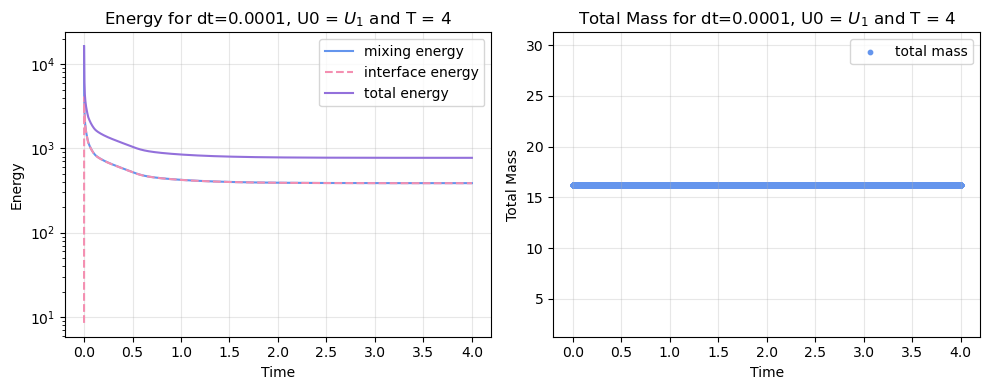

T_sd = 9.0e-04


In [25]:
T = 4
dt = 1e-4
U0 = U0_1

cahn_hilliard_energy_mass_plotter(T, dt, U0, "IMEX_Song_CH", True)

The total mass remains numerically constant throughout the entire period. This is just as expected due to conservation of mass as shown in task 1.3. Any slight fluctuations observed are most likely due to the inherent limitations of floating-point precision, which can result in small inaccuracies in the representation of values. We see that the mass remains constant for all scenarios.

Plot with IMEX_song_solver


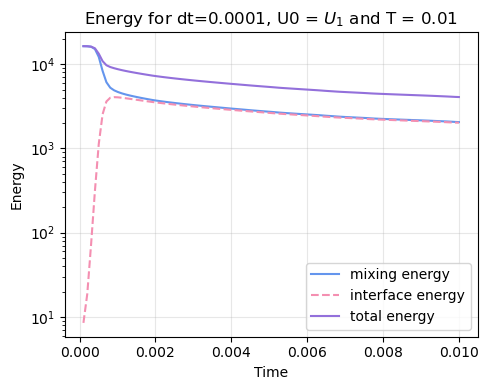

T_sd = 9.1e-04


Plot with cahn_hilliard_backward_euler


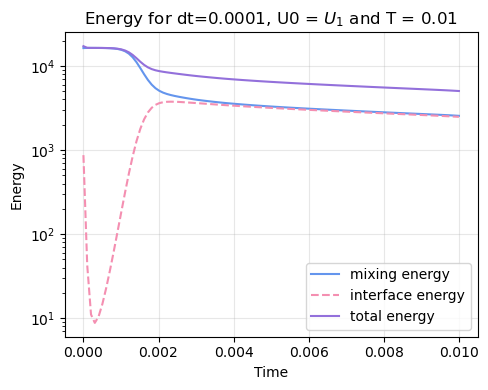

T_sd = 2.3e-03


In [26]:
T = 0.01

print("Plot with IMEX_song_solver")
cahn_hilliard_energy_mass_plotter(T, dt, U0, "IMEX_Song_CH")

print("\n\nPlot with cahn_hilliard_backward_euler")
cahn_hilliard_energy_mass_plotter(T, dt, U0, "IMEX_Euler_CH")

The two different solvers are quite similar. However, there are some prominent differences. Firstly, there is an irregularity in the first plot with the backward Euler method and the IMEX\_song\_solver gives an overall smoother curvature. Some animations were created to look for any obvious differences, and the end result looks quite different, so the choice of solver definitely has an effect. Also, with bigger time steps, the IMEX\_song\_solver has a better representation of the spinodal decomposition whereas the backward Euler method is not able to represent this for $dt=10^{-3}$ in the shorter time interval $T = 0.01$.  

We did tests for smaller time steps $dt$ for both solvers and saw that the spinodal decomposition time for the IMEX\_song\_solver stabilized faster (around $dt = 10^{-6}$) than the backward Euler method. This is another reason for why we decided the IMEX\_song\_solver was better at simulating the given scenario. Further, for the backward Euler method the interface energy starts around $10^3$ and rapidly drops for the first milliseconds before spiking as initially expected. This is not expected behaviour for the interface energy, which will be explained further on, and therefore indicates that there are some weaknesses with the numerical method. Therefore, the IMEX\_song\_solver is used in further evaluations of the different initial conditions.

As expected, the different energies decrease over time as the system seeks equilibrium. As described in the task, the mixing energy drives the system from a homogeneous state towards a separated state, while the interface energy works to minimize the surface area. Together, these two effects create complex patterns during the separation process. The total energy is governed by the dynamics of the system, aiming to minimize the system's free energy. However, at the beginning, the interface energy should experience a spike due to spinodal decomposition, where the mixture transitions from a homogeneous state and begins to separate. This is not what is observed for the backwards Euler solver and is a big reason for not choosing this solver for further analysis. Nevertheless, this behavior is reflected in the other plots, where we observe the initial spike in energy followed by a decrease over time for $T = 4$. For $T = 0.01$, the spinodal decomposition is visible in more detail, demonstrating the early-stage separation more clearly. 

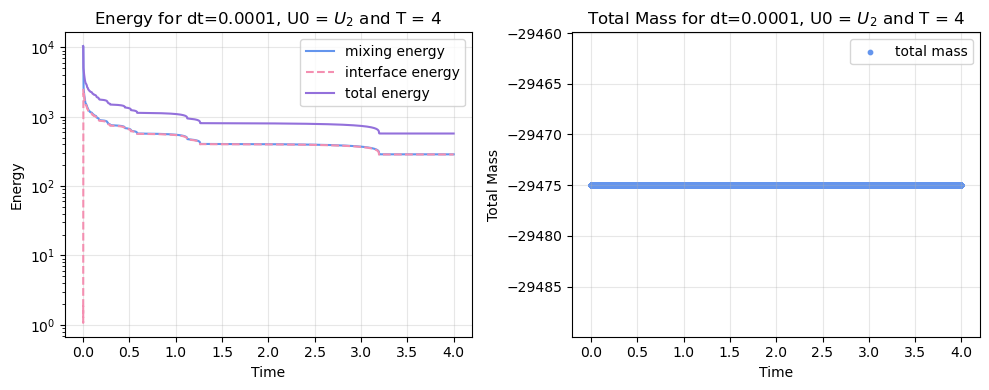

T_sd = 2.3e-03


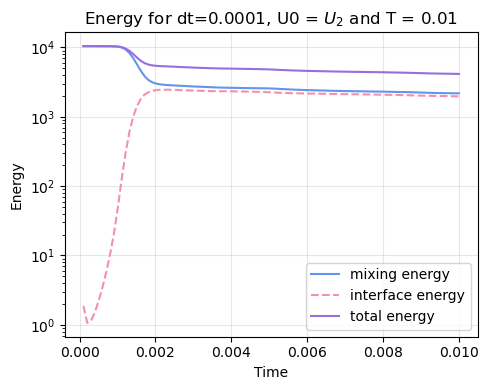

T_sd = 2.2e-03


In [27]:
T = 4
U0 = U0_2

cahn_hilliard_energy_mass_plotter(T, dt, U0, "IMEX_Song_CH", True)

T = 0.01

cahn_hilliard_energy_mass_plotter(T, dt, U0, "IMEX_Song_CH")

There are two different initial conditions for the energy, where $U_2 = -0.45 + 0.05rand(x,y)$ gives a more jagged form and $U_1 = 0.05rand(x,y)$ has a smooth curvature. This behavior, with small, sudden jumps, instead of a completely smooth settling, could be explained form the negative bias. The negative bias will result in stronger local instabilities and steeper energy gradients, which may result in the sudden downwards jumps in total energy observed in the plot. Moreover, the animations show some differences. As one of the initial conditions has a negative bias, the animation for $U_0 = U_2$ starts with a more prominent orange color, indicating a more negative relationship between the two substances compared to $U_0 = U_1$, where the color is closer to white. This is confirmed by the mass calculations, which show around $16$ for $U_0 = U_1$ and around $-29000$ for $U_0 = U_2$, demonstrating a large skewed distribution of the substances.

When looking at the Ostwald ripening and spinodal decomposition, the difference in the slope is more prominent for the smaller time steps. Furthermore, the spinodal decomposition doesn't last as long when looking at the animations and plots made with smaller time steps, and $T_{sd}$ is therefore marginally larger. For example, one of the plots for $U_0 =U_2$ and $T = 0.01$ did not capture the whole spinodal decomposition, because of the longer duration for bigger timestep. Therefore, the smaller time steps appears to give a more exact solution, which sounds reasonable. 

Therefore, we look at the plots with the smaller time steps to determine where the spinodal decomposition and Ostwald ripening is happening. For $U_0=U_1$, $T_{sd}=0.0009$ approximately, and the Ostwald ripening is happening after this. For $U_0=U_2$, $T_{sd}$ is around $0.0022$ and the Ostwald ripening, again, occurs after the spinodal decomposition. 

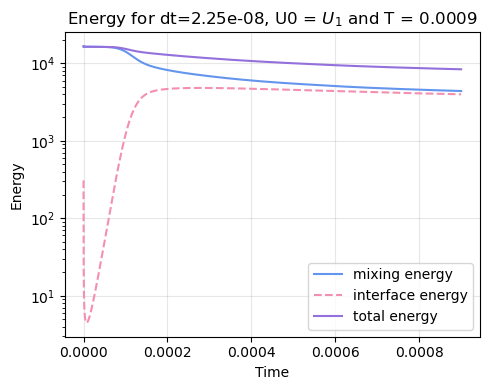

T_sd = 2.8e-04


In [28]:
T = 0.0009   # Which is T_sd from previous calcs 
dt = T/40000 # dt for Nt = 40000
U0 = U0_1

cahn_hilliard_energy_mass_plotter(T, dt, U0, "IMEX_Song_CH")

As noted earlier, when the time step size gets smaller, $T_{sd}$ decreases as well until it is stabilized at around $T \approx 2.8 \cdot 10^{-4}$ (when $dt \leq 10^{-6}$). We will then be using $T_{sd} = 2.8 \cdot 10^{-4}$ as our reference point for the plotting of the gif, and $dt = 10^{-6}$.

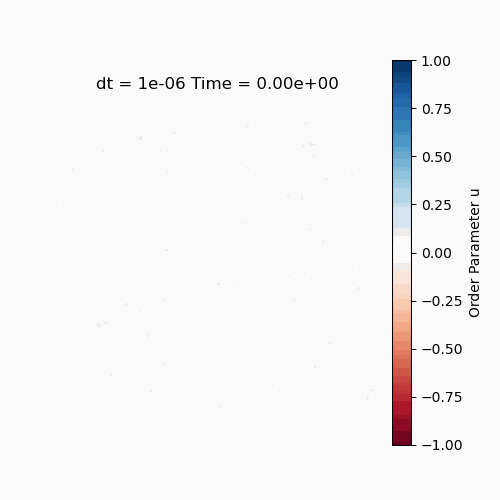

In [29]:
from matplotlib import animation
from IPython.display import Image, display

# Run solver
T       = 2 * 2.8e-4
Nt      = 560
solver  = IMEX_song_solver(kappa=kappa, X=X, Y=Y, U0=U0_1, t0=t0, T=T, Nt=Nt, g=None, alpha=1.5, coefficients='c2')

phase_field = []

# Extract snapshots for every 56th time (10 snapshots)
for i, (U_hat, t) in enumerate(solver):
    if i % 56 == 0:
        phase_field.append(ifft2(U_hat).real)

# Set up the figure and plot
fig, ax = plt.subplots(figsize=(5, 5))
cax     = ax.imshow(phase_field[0], cmap='RdBu', origin='lower', vmin=-1, vmax=1)
cbar    = fig.colorbar(cax, ax=ax, label="Order Parameter u")
title   = ax.set_title(f"Time = {0}")
ax.axis("off")

# Update function for animation
def update(frame):
    cax.set_data(phase_field[frame])
    if frame == 5:
        title.set_text(f"dt = {(T/Nt):.0e} Time = $T_sd$")
    else:
        title.set_text(f"dt = {(T/Nt):.0e} Time = {frame * (T*56 / Nt):.2e}")
    return [cax, title]

# Create the animation
anim = animation.FuncAnimation(fig, update, frames=len(phase_field), blit=False)

# Save as GIF
anim.save("phase_separation_full_animation.gif", writer='pillow', fps=0.7)

# Display inline in Jupyter
plt.close(fig)
display(Image(filename="phase_separation_full_animation.gif"))

Here is an animated gif of the concentration field simulated by the IMEX_song_solver on the time interval $I = [0, \ 5.6 \cdot 10^{-4}]$ and with time step size $dt = 10^{-6}$. The gif consists of five snapshots during the spinodal decomposition, at $Time = T_{sd} = 2.8 \cdot 10^{-4}$ and four more snapshots of the Ostwald ripening process after.